# CML vs BIDS Comparison

Using `bids_validation` package with `CMLBIDSReader`.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import os
import numpy as np
import pandas as pd
import cmlreaders as cml
import matplotlib.pyplot as plt
%matplotlib inline

from cmldask import CMLDask
from dask.distributed import wait, progress

from eeg_validation import (
    EventsPipeline,
    RawSignalPipeline,
    EpochedPipeline,
    MontagePipeline,
    DigitalSignalPipeline
)
from eeg_validation.io import load_and_concat
from eeg_validation.plotting import plot_comparison_results

pd.options.display.max_rows = 100
pd.options.display.max_columns = 50
import sys
sys.path.append("/home1/zrentala/bidsreader")
from bidsreader import CMLBIDSReader

## 1. Configuration

In [2]:
# ---- Shared settings ----
REL_START = 200      # ms
REL_STOP  = 500     # ms
BUFFER_MS = 500     # ms
tmin = -BUFFER_MS
tmax = REL_STOP + BUFFER_MS

MAX_SUBJECTS = 10
SUBJECTS_TO_EXCLUDE = {"LTP001", "LTP9992", "LTP9993"}

# Set to True to skip sessions whose output CSVs already exist
SKIP_IF_EXISTS = True


In [3]:


def load_dfs(file_categories, final_dir):
    """Load aggregated CSVs from the final directory for each category."""
    dfs = {}
    for cat in file_categories:
        path = os.path.join(final_dir, f"{cat}_all.csv")
        if os.path.exists(path):
            try: 
                dfs[cat] = pd.read_csv(path)
                print(f"{cat}: loaded {len(dfs[cat])} rows from {path}")
            except:
                print(f"Couldn't load {cat}")
        else:
            print(f"Skipping {cat} (file not found: {path})")
    return dfs


def get_completed_sessions(final_dir, summary_files=None):
    """Return set of (subject, session) tuples that appear in ALL *summary* files."""
    import glob
    if summary_files is not None:
        summary_files = [os.path.join(final_dir, f) for f in summary_files]
    else:
        summary_files = sorted(glob.glob(os.path.join(final_dir, "*summary*_all.csv")))
    if not summary_files:
        return set()

    sets = []
    for path in summary_files:
        df = pd.read_csv(path, usecols=["subject", "session"]).dropna(subset=["subject", "session"])
        pairs = set(zip(df["subject"], df["session"].astype(int)))
        sets.append(pairs)
        print(f"  {os.path.basename(path)}: {len(pairs)} (subject, session) pairs")

    completed = sets[0]
    for s in sets[1:]:
        completed &= s
    print(f"  -> {len(completed)} sessions completed across all {len(summary_files)} summary files")
    return completed


In [4]:
import ast
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ---------------- summary stats (computed once, passed into plots) ----------------

def expected_from_jobs(jobs_df):
    """Build the ground-truth n_subjects from a jobs DataFrame
    (e.g. df_ltp / df_ram from cml.get_data_index()), so n_subjects is
    constant across all plots in a pipeline regardless of which sessions
    happen to appear in each summary df."""
    return {
        "n_subjects": int(jobs_df["subject"].nunique()),
        "n_comparisons": int(len(jobs_df)),  # informational; not used as a denom
    }




def _padded_mean_se(values, target_n):
    """Mean and SE assuming any missing entries (target_n - len(values))
    are 0 — i.e. missing subjects/files/epochs contribute no difference."""
    arr = np.asarray(list(values), dtype=float)
    n_missing = max(0, int(target_n) - len(arr))
    if n_missing > 0:
        arr = np.concatenate([arr, np.zeros(n_missing)])
    if len(arr) == 0:
        return 0.0, 0.0
    mean = float(arr.mean())
    se = float(arr.std(ddof=1) / np.sqrt(len(arr))) if len(arr) > 1 else 0.0
    return mean, se


def _expected_n_comp(df, expected):
    """Row-level denominator that pads missing rows with 0:
    use len(df) when df has at least as many rows as expected (fan-out
    case), otherwise use expected n_comparisons (missing-rows case)."""
    if expected is None:
        return int(len(df))
    return int(max(len(df), int(expected.get("n_comparisons", 0))))

def _resolve_denoms(df, expected):
    """n_subjects: from expected jobs df (constant per pipeline).
    n_comparisons: max(len(df), expected n_comparisons) — pads missing
    rows with 0 so denominators stay the truth, but also handles
    fan-out dfs (epoch event_types) where len(df) > # sessions."""
    n_comp = _expected_n_comp(df, expected)
    if expected is not None:
        n_subs = int(expected["n_subjects"])
    else:
        n_subs = int(df["subject"].nunique())
    return n_subs, n_comp


def signal_summary_stats(df, expected=None):
    n_subs, n_comp = _resolve_denoms(df, expected)
    bad = df.query("n_close_diff_channels > 0")
    n_subs_close = int(bad["subject"].nunique())
    n_comp_close = int(len(bad))
    # Per-subject mean: each subject's per-row mean, padded with 0 for
    # subjects expected but absent from df.
    per_sub_means = df.groupby("subject")["n_close_diff_channels"].mean().values
    avg_per_sub, _ = _padded_mean_se(per_sub_means, n_subs)
    # Per-row mean: pad missing rows with 0 (n_comp already padded).
    avg_per_row, _ = _padded_mean_se(df["n_close_diff_channels"].values, n_comp)
    mse_mean, mse_se = _padded_mean_se(df["mse"].values, n_comp)
    # MSE restricted to rows with at least one channel above tolerance
    mse_mean_diff = float(bad["mse"].mean()) if len(bad) else 0.0
    mse_se_diff = float(bad["mse"].sem()) if len(bad) > 1 else 0.0
    return {
        "kind": "signal",
        "n_subjects": n_subs,
        "n_comparisons": n_comp,
        "n_subs_close": n_subs_close,
        "n_comp_close": n_comp_close,
        "pct_subs_close": (n_subs_close / n_subs) if n_subs else 0,
        "pct_comp_close": (n_comp_close / n_comp) if n_comp else 0,
        "avg_close_per_sub": avg_per_sub,
        "avg_close_per_comp": avg_per_row,
        "mse_mean": mse_mean,
        "mse_se": mse_se,
        "mse_mean_diff": mse_mean_diff,
        "mse_se_diff": mse_se_diff,
    }


def time_summary_stats(df, expected=None):
    n_subs, n_comp = _resolve_denoms(df, expected)
    bad = df.query("n_close_time_diff > 0")
    n_subs_close = int(bad["subject"].nunique())
    n_comp_close = int(len(bad))
    per_sub_means = df.groupby("subject")["n_close_time_diff"].mean().values
    avg_per_sub, _ = _padded_mean_se(per_sub_means, n_subs)
    avg_per_row, _ = _padded_mean_se(df["n_close_time_diff"].values, n_comp)
    mse_mean, mse_se = _padded_mean_se(df["mse_time"].values, n_comp)
    mse_mean_diff = float(bad["mse_time"].mean()) if len(bad) else 0.0
    mse_se_diff = float(bad["mse_time"].sem()) if len(bad) > 1 else 0.0
    return {
        "kind": "time",
        "n_subjects": n_subs,
        "n_comparisons": n_comp,
        "n_subs_close": n_subs_close,
        "n_comp_close": n_comp_close,
        "pct_subs_close": (n_subs_close / n_subs) if n_subs else 0,
        "pct_comp_close": (n_comp_close / n_comp) if n_comp else 0,
        "avg_close_per_sub": avg_per_sub,
        "avg_close_per_comp": avg_per_row,
        "mse_mean": mse_mean,
        "mse_se": mse_se,
        "mse_mean_diff": mse_mean_diff,
        "mse_se_diff": mse_se_diff,
    }


def behavior_summary_stats(df, expected=None):
    n_subs, n_comp = _resolve_denoms(df, expected)
    bad = df.query("n_differing_columns > 0")
    n_subs_diff = int(bad["subject"].nunique())
    n_comp_diff = int(len(bad))
    per_sub_means = df.groupby("subject")["n_differing_columns"].mean().values
    avg_per_sub, _ = _padded_mean_se(per_sub_means, n_subs)
    avg_per_row, _ = _padded_mean_se(df["n_differing_columns"].values, n_comp)
    return {
        "kind": "behavior",
        "n_subjects": n_subs,
        "n_comparisons": n_comp,
        "n_subs_diff": n_subs_diff,
        "n_comp_diff": n_comp_diff,
        "pct_subs_diff": (n_subs_diff / n_subs) if n_subs else 0,
        "pct_comp_diff": (n_comp_diff / n_comp) if n_comp else 0,
        "avg_diff_cols_per_sub": avg_per_sub,
        "avg_diff_cols_per_comp": avg_per_row,
    }


def montage_summary_stats(df, expected=None):
    n_rows = len(df)
    if expected is not None:
        n_subs = int(expected["n_subjects"])
    else:
        n_subs = int(df["subject"].nunique())
    contacts = int(df["contacts_skipped"].astype(bool).sum()) if "contacts_skipped" in df.columns else 0
    pairs = int(df["pairs_skipped"].astype(bool).sum()) if "pairs_skipped" in df.columns else 0
    return {
        "kind": "montage",
        "n_subjects": n_subs,
        "n_rows": n_rows,
        "n_contacts_skipped": contacts,
        "n_pairs_skipped": pairs,
        "pct_contacts_skipped": (contacts / n_rows) if n_rows else 0,
        "pct_pairs_skipped": (pairs / n_rows) if n_rows else 0,
    }


# ---------------- units & titles ----------------

# What each row in a summary df represents.
_DF_UNIT = {
    "df_raw_summary": "files",
    "df_raw_time": "files",
    "df_epoch_summary": "epochs",
    "df_epoch_time": "epochs",
    "df_time": "files",
    "df_behavior_summary": "behavior files",
    "df_contacts_summary": "montage files",
    "df_pairs_summary": "montage files",
    "df_montage_summary": "montage files",
}


def _unit_for(df_key, default="comparisons"):
    return _DF_UNIT.get(df_key, default)


def _singular(unit):
    return unit[:-1] if unit.endswith("s") else unit


def _basic_title(name, n_subjects, n_units, unit):
    return f"{name}\ncomparing {int(n_units)} {unit} across {int(n_subjects)} subjects"


# ---------------- saving ----------------

def _save_fig(fig, save_dir, filename):
    if save_dir is None:
        return
    p = Path(save_dir)
    p.mkdir(parents=True, exist_ok=True)
    fig.savefig(p / filename, dpi=150, bbox_inches="tight")


def save_summary_stats(stats_by_df, save_dir, filename="summary_stats.json"):
    if save_dir is None:
        return
    p = Path(save_dir)
    p.mkdir(parents=True, exist_ok=True)
    with open(p / filename, "w") as f:
        json.dump(stats_by_df, f, indent=2, default=str)


# ---------------- generic 2-panel counts/pcts plot ----------------

def _plot_counts_pcts(stats, name, unit,
                      total_keys, diff_keys, pct_keys,
                      save_dir=None, filename=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    title = _basic_title(name, stats["n_subjects"], stats["n_comparisons"], unit)
    count_labels = ["subjects", unit]
    pct_labels = ["% subjects", f"% {unit}"]

    # counts panel
    ax = axes[0]
    x = np.arange(len(count_labels))
    w = 0.38
    totals = [stats[k] for k in total_keys]
    diffs = [stats[k] for k in diff_keys]
    b1 = ax.bar(x - w / 2, totals, w, label="total", color="lightgray")
    b2 = ax.bar(x + w / 2, diffs, w, label="with diff > rtol", color="C3")
    for bars in (b1, b2):
        for b in bars:
            ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                    f"{int(b.get_height())}", ha="center", va="bottom", fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(count_labels)
    ax.set_ylabel("count")
    ax.set_title(title, fontsize=10)
    ax.legend(); ax.grid(axis="y", alpha=0.3)

    # pcts panel
    ax = axes[1]
    vals = [stats[k] * 100 for k in pct_keys]
    bars = ax.bar(pct_labels, vals, color="C3")
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
    ax.set_ylabel("percent")
    ax.set_ylim(0, 105)
    ax.set_title(title, fontsize=10)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    _save_fig(fig, save_dir, filename or f"{name}_summary.png")
    plt.show()
    return fig


def plot_signal_summary(stats, name="signal", unit="files", save_dir=None):
    return _plot_counts_pcts(
        stats, name, unit,
        total_keys=["n_subjects", "n_comparisons"],
        diff_keys=["n_subs_close", "n_comp_close"],
        pct_keys=["pct_subs_close", "pct_comp_close"],
        save_dir=save_dir, filename=f"{name}_signal_summary.png",
    )


def plot_time_summary(stats, name="time", unit="files", save_dir=None):
    return _plot_counts_pcts(
        stats, name, unit,
        total_keys=["n_subjects", "n_comparisons"],
        diff_keys=["n_subs_close", "n_comp_close"],
        pct_keys=["pct_subs_close", "pct_comp_close"],
        save_dir=save_dir, filename=f"{name}_time_summary.png",
    )


def plot_behavior_summary(stats, name="behavior", unit="files", save_dir=None):
    return _plot_counts_pcts(
        stats, name, unit,
        total_keys=["n_subjects", "n_comparisons"],
        diff_keys=["n_subs_diff", "n_comp_diff"],
        pct_keys=["pct_subs_diff", "pct_comp_diff"],
        save_dir=save_dir, filename=f"{name}_behavior_summary.png",
    )


def plot_montage_summary(stats, name="montage", unit="montage files", save_dir=None):
    fig, ax = plt.subplots(figsize=(7, 5))
    cats = ["contacts_skipped", "pairs_skipped"]
    vals = [stats["n_contacts_skipped"], stats["n_pairs_skipped"]]
    bars = ax.bar(cats, vals, color="C3")
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                f"{int(v)}", ha="center", va="bottom", fontsize=9)
    ax.set_ylabel(f"# {unit}")
    ax.set_title(_basic_title(name, stats["n_subjects"], stats["n_rows"], unit), fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    _save_fig(fig, save_dir, f"{name}_montage_summary.png")
    plt.show()
    return fig


# ---------------- avg + MSE metric plots ----------------

def _plot_metrics(stats, name, unit, mse_label, avg_label_unit,
                  avg_sub_key, avg_comp_key, mse_mean_key, mse_se_key,
                  save_dir=None, filename=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    title = _basic_title(name, stats["n_subjects"], stats["n_comparisons"], unit)

    # avg counts panel
    ax = axes[0]
    cats = ["avg / subject", f"avg / {_singular(unit)}"]
    vals = [stats[avg_sub_key], stats[avg_comp_key]]
    bars = ax.bar(cats, vals, color="C0")
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                f"{v:.2f}", ha="center", va="bottom", fontsize=9)
    ax.set_ylabel(avg_label_unit)
    ax.set_title(title, fontsize=10)
    ax.grid(axis="y", alpha=0.3)

    # MSE panel with SE error bars: all rows (incl. zero-padded) vs only
    # rows with diff > rtol
    ax = axes[1]
    mse_all = stats[mse_mean_key]
    se_all = stats[mse_se_key]
    mse_diff = stats.get("mse_mean_diff", 0.0)
    se_diff = stats.get("mse_se_diff", 0.0)
    cats = ["all", "with diff > rtol"]
    means = [mse_all, mse_diff]
    ses = [se_all, se_diff]
    bars = ax.bar(cats, means, yerr=ses, capsize=8,
                  color=["lightgray", "C3"],
                  error_kw={"elinewidth": 1.5})
    for i, (b, m, e) in enumerate(zip(bars, means, ses)):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                f"{m:.2e}\n\u00b1{e:.2e}", ha="center", va="bottom", fontsize=9)
    ax.set_ylabel(mse_label)
    ax.set_title(title, fontsize=10)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    _save_fig(fig, save_dir, filename or f"{name}_metrics.png")
    plt.show()
    return fig


def plot_signal_metrics(stats, name="signal", unit="files", save_dir=None):
    return _plot_metrics(
        stats, name, unit,
        mse_label="MSE",
        avg_label_unit="# channels with diff > rtol",
        avg_sub_key="avg_close_per_sub",
        avg_comp_key="avg_close_per_comp",
        mse_mean_key="mse_mean", mse_se_key="mse_se",
        save_dir=save_dir, filename=f"{name}_signal_metrics.png",
    )


def plot_time_metrics(stats, name="time", unit="files", save_dir=None):
    return _plot_metrics(
        stats, name, unit,
        mse_label="MSE_time",
        avg_label_unit="# events with diff > rtol",
        avg_sub_key="avg_close_per_sub",
        avg_comp_key="avg_close_per_comp",
        mse_mean_key="mse_mean", mse_se_key="mse_se",
        save_dir=save_dir, filename=f"{name}_time_metrics.png",
    )


# ---------------- top-N items (channels / columns) ----------------

def _parse_listcol(cell):
    if isinstance(cell, list):
        return cell
    if pd.isna(cell):
        return []
    try:
        v = ast.literal_eval(cell)
        return list(v) if isinstance(v, (list, tuple)) else []
    except (ValueError, SyntaxError):
        return []


def _top_items(df, list_col, top_n=100):
    per_comp = Counter()
    sub_pairs = set()
    for sub, raw in zip(df["subject"], df[list_col]):
        items = _parse_listcol(raw)
        per_comp.update(items)
        for it in items:
            sub_pairs.add((sub, it))
    sub_counts = Counter()
    for (_, it) in sub_pairs:
        sub_counts[it] += 1
    s_comp = pd.Series(per_comp).sort_values(ascending=False).head(top_n)
    s_sub = pd.Series(sub_counts).sort_values(ascending=False).head(top_n)
    return s_comp, s_sub


def plot_top_items(df, list_col, name="df", top_n=100, item_label="channel",
                   save_dir=None, filename=None):
    if list_col not in df.columns:
        return None
    s_comp, s_sub = _top_items(df, list_col, top_n=top_n)
    if s_comp.empty and s_sub.empty:
        return None
    n_bars = max(len(s_comp), len(s_sub))
    shown_n = min(top_n, n_bars)
    # ~0.32" per bar plus a little headroom; clamp to a sensible range
    height = max(3.0, min(40.0, 1.5 + 0.32 * n_bars))
    fig, axes = plt.subplots(1, 2, figsize=(14, height))
    axes[0].barh(s_comp.index[::-1], s_comp.values[::-1], color="C0")
    axes[0].set_title(f"{name}: top {shown_n} {item_label}s by # comparisons")
    axes[0].set_xlabel(f"# comparisons with {item_label} diff")
    axes[0].grid(axis="x", alpha=0.3)
    axes[1].barh(s_sub.index[::-1], s_sub.values[::-1], color="C2")
    axes[1].set_title(f"{name}: top {shown_n} {item_label}s by # subjects")
    axes[1].set_xlabel(f"# subjects with {item_label} diff")
    axes[1].grid(axis="x", alpha=0.3)
    plt.tight_layout()
    _save_fig(fig, save_dir, filename or f"{name}_top_{item_label}s.png")
    plt.show()
    return fig


# ---------------- monopolar/bipolar acquisition breakdown ----------------

def plot_acquisition_breakdown(df, name="df", diff_col="n_close_diff_channels",
                               save_dir=None):
    """Two-panel: monopolar vs bipolar file counts and percentages with diff > rtol.
    A 'file' = one (subject, experiment, session, acquisition) tuple."""
    if "acquisition" not in df.columns or diff_col not in df.columns:
        return None
    file_keys = [c for c in ("subject", "experiment", "session", "acquisition") if c in df.columns]
    files = df.drop_duplicates(file_keys)
    diff_files = df[df[diff_col] > 0].drop_duplicates(file_keys)
    totals = files["acquisition"].value_counts()
    diffs = diff_files["acquisition"].value_counts().reindex(totals.index, fill_value=0)
    pcts = (diffs / totals.replace(0, np.nan) * 100).fillna(0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    title = f"{name}: monopolar vs bipolar files"

    # counts panel
    ax = axes[0]
    x = np.arange(len(totals))
    w = 0.38
    b1 = ax.bar(x - w / 2, totals.values, w, label="total", color="lightgray")
    b2 = ax.bar(x + w / 2, diffs.values, w, label="with diff > rtol", color="C3")
    for bars in (b1, b2):
        for b in bars:
            ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                    f"{int(b.get_height())}", ha="center", va="bottom", fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(totals.index)
    ax.set_ylabel("# files compared")
    ax.set_title(title, fontsize=10)
    ax.legend(); ax.grid(axis="y", alpha=0.3)

    # percentage panel
    ax = axes[1]
    bars = ax.bar(pcts.index, pcts.values, color="C3")
    for b, v in zip(bars, pcts.values):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
    ax.set_ylabel("% files with diff > rtol")
    ax.set_ylim(0, 105)
    ax.set_title(title, fontsize=10)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    _save_fig(fig, save_dir, f"{name}_acquisition.png")
    plt.show()
    return fig


# ---------------- driver: run all plots for a pipeline ----------------

_SIGNAL_KEYS = ["df_epoch_summary", "df_raw_summary"]
_TIME_KEYS = ["df_epoch_time", "df_raw_time", "df_time"]
_BEHAVIOR_KEYS = ["df_behavior_summary", "df_contacts_summary", "df_pairs_summary"]
_MONTAGE_KEYS = ["df_montage_summary"]


def run_all_plots(dfs, name, save_dir=None, expected=None):
    """Compute summary stats and produce all plots for a pipeline's df dict.

    Returns a dict of {df_key: stats} and (optionally) saves all plots and
    a summary_stats.json under save_dir.
    """
    all_stats = {}

    # signal dfs
    for key in _SIGNAL_KEYS:
        if key not in dfs:
            continue
        df = dfs[key]
        s = signal_summary_stats(df, expected=expected)
        all_stats[key] = s
        label = f"{name}_{key}"
        unit = _unit_for(key)
        plot_signal_summary(s, name=label, unit=unit, save_dir=save_dir)
        plot_signal_metrics(s, name=label, unit=unit, save_dir=save_dir)
        plot_top_items(df, "close_diff_channels", name=label, top_n=100,
                       item_label="channel", save_dir=save_dir)
        plot_acquisition_breakdown(df, name=label,
                                   diff_col="n_close_diff_channels",
                                   save_dir=save_dir)

    # time dfs
    for key in _TIME_KEYS:
        if key not in dfs:
            continue
        df = dfs[key]
        s = time_summary_stats(df, expected=expected)
        all_stats[key] = s
        label = f"{name}_{key}"
        unit = _unit_for(key)
        plot_time_summary(s, name=label, unit=unit, save_dir=save_dir)
        plot_time_metrics(s, name=label, unit=unit, save_dir=save_dir)
        plot_acquisition_breakdown(df, name=label,
                                   diff_col="n_close_time_diff",
                                   save_dir=save_dir)

    # behavior / contacts / pairs dfs
    for key in _BEHAVIOR_KEYS:
        if key not in dfs:
            continue
        df = dfs[key]
        s = behavior_summary_stats(df, expected=expected)
        all_stats[key] = s
        label = f"{name}_{key}"
        unit = _unit_for(key)
        plot_behavior_summary(s, name=label, unit=unit, save_dir=save_dir)
        plot_top_items(df, "differing_columns", name=label, top_n=100,
                       item_label="column", save_dir=save_dir)

    # montage dfs
    for key in _MONTAGE_KEYS:
        if key not in dfs:
            continue
        df = dfs[key]
        s = montage_summary_stats(df, expected=expected)
        all_stats[key] = s
        label = f"{name}_{key}"
        unit = _unit_for(key)
        plot_montage_summary(s, name=label, unit=unit, save_dir=save_dir)

    save_summary_stats(all_stats, save_dir, filename=f"{name}_summary_stats.json")
    return all_stats


---
## 2. Scalp / LTP Comparisons

### 2a. Select subjects & sessions

In [12]:
ltp_experiments = ["VFFR"]
ltp_bids_root   = os.path.abspath("/data/LTP_BIDS/VFFR")
ltp_out_path    = os.path.abspath("results/VFFR_results/")

df = cml.get_data_index()
df_exp = df[df["experiment"].isin(ltp_experiments)].copy()
df_exp = df_exp[~df_exp["subject"].isin(SUBJECTS_TO_EXCLUDE)]

dfs = []
for exp in ltp_experiments:
    df_this = df_exp[df_exp["experiment"] == exp]
    subjects = df_this["subject"].drop_duplicates().sort_values()
    dfs.append(df_this[df_this["subject"].isin(subjects)])

df_ltp = pd.concat(dfs, ignore_index=True)
print(f"LTP jobs: {len(df_ltp)} sessions across {df_ltp['subject'].nunique()} subjects")
df_ltp[["subject", "experiment", "session"]]


LTP jobs: 465 sessions across 57 subjects


,subject,experiment,session
0,LTP229,VFFR,0
1,LTP229,VFFR,1
2,LTP229,VFFR,2
3,LTP229,VFFR,3
4,LTP229,VFFR,4
...,...,...,...
460,LTP439,VFFR,2
461,LTP439,VFFR,3
462,LTP439,VFFR,4
463,LTP440,VFFR,0


### 2b. Run Raw + Epoched EEG comparisons

In [13]:
for _, row in df_ltp.iterrows():
    sub, exp, sess = row["subject"], row["experiment"], int(row["session"])
    bids_root = ltp_bids_root

    # --- Raw (scalp: no acquisition) ---
    try:
        result = RawSignalPipeline(
            sub, exp, sess, bids_root, ltp_out_path,
            skip_if_exists=SKIP_IF_EXISTS,
        ).run()
        tag = "SKIP" if isinstance(result, dict) and result.get("skipped") else "DONE"
        print(f"[{tag}] Raw  | {sub} | {exp} | {sess}")
    except Exception as e:
        print(f"[FAIL] Raw  | {sub} | {exp} | {sess}: {e}")

    # --- Epoched (scalp: no acquisition) ---
    try:
        result = EpochedPipeline(
            sub, exp, sess, bids_root, ltp_out_path,
            skip_if_exists=SKIP_IF_EXISTS,
            tmin=tmin, tmax=tmax, verbose=True,
        ).run()
        tag = "SKIP" if isinstance(result, dict) and result.get("skipped") else "DONE"
        print(f"[{tag}] Epoch | {sub} | {exp} | {sess}")
    except Exception as e:
        print(f"[FAIL] Epoch | {sub} | {exp} | {sess}: {e}")

[SKIP] Raw  | LTP229 | VFFR | 0

[EpochedPipeline] Starting pipeline for LTP229_VFFR_0
  Skipping: all 2 output files already exist
[SKIP] Epoch | LTP229 | VFFR | 0
[SKIP] Raw  | LTP229 | VFFR | 1

[EpochedPipeline] Starting pipeline for LTP229_VFFR_1
  Skipping: all 2 output files already exist
[SKIP] Epoch | LTP229 | VFFR | 1
[SKIP] Raw  | LTP229 | VFFR | 2

[EpochedPipeline] Starting pipeline for LTP229_VFFR_2
  Skipping: all 2 output files already exist
[SKIP] Epoch | LTP229 | VFFR | 2
[SKIP] Raw  | LTP229 | VFFR | 3

[EpochedPipeline] Starting pipeline for LTP229_VFFR_3
  Skipping: all 2 output files already exist
[SKIP] Epoch | LTP229 | VFFR | 3
[SKIP] Raw  | LTP229 | VFFR | 4

[EpochedPipeline] Starting pipeline for LTP229_VFFR_4
  Skipping: all 2 output files already exist
[SKIP] Epoch | LTP229 | VFFR | 4
[SKIP] Raw  | LTP229 | VFFR | 5

[EpochedPipeline] Starting pipeline for LTP229_VFFR_5
  Skipping: all 2 output files already exist
[SKIP] Epoch | LTP229 | VFFR | 5
[SKIP] Raw

KeyboardInterrupt: 

In [ ]:
def run_ltp_raw(row_dict):
    sub, exp, sess = row_dict["subject"], row_dict["experiment"], int(row_dict["session"])
    bids_root = ltp_bids_root
    out_path = ltp_out_path

    try:
        result = RawSignalPipeline(
            sub, exp, sess, bids_root, out_path,
            skip_if_exists=True,
        ).run()
    except Exception as e:
        result = {"error": str(e)}

    return {"subject": sub, "experiment": exp, "session": sess, "raw": result}

client = CMLDask.new_dask_client_slurm("logs/" + ltp_out_path, "100GB", max_n_jobs=100)
futures = client.map(run_ltp_raw, df_ltp.to_dict("records"))
progress(futures)
wait(futures)

finished = CMLDask.filter_futures(futures)
ltp_raw_results = client.gather(finished)
print(f"Completed {len(ltp_raw_results)} / {len(futures)} jobs")
client.shutdown()

# --- Parallel version of LTP Epoched EEG comparisons using cmldask ---

def run_ltp_epoch(row_dict):
    sub, exp, sess = row_dict["subject"], row_dict["experiment"], int(row_dict["session"])
    bids_root = ltp_bids_root
    out_path = ltp_out_path

    try:
        result = EpochedPipeline(
            sub, exp, sess, bids_root, out_path,
            skip_if_exists=True,
            tmin=tmin, tmax=tmax, verbose=True,
        ).run()
    except Exception as e:
        result = {"error": str(e)}

    return {"subject": sub, "experiment": exp, "session": sess, "epoch": result}

client = CMLDask.new_dask_client_slurm("logs/" + ltp_out_path, "100GB", max_n_jobs=100)
futures = client.map(run_ltp_epoch, df_ltp.to_dict("records"))
progress(futures)
wait(futures)

finished = CMLDask.filter_futures(futures)
ltp_epoch_results = client.gather(finished)
print(f"Completed {len(ltp_epoch_results)} / {len(futures)} jobs")
client.shutdown()


### 2c. Run Behavioral Events comparison

In [ ]:
for _, row in df_ltp.iterrows():
    sub, exp, sess = row["subject"], row["experiment"], int(row["session"])

    try:
        result = EventsPipeline(
            sub, exp, sess, ltp_bids_root, ltp_out_path,
            skip_if_exists=SKIP_IF_EXISTS,
        ).run()
        tag = "SKIP" if isinstance(result, dict) and result.get("skipped") else "DONE"
        print(f"[{tag}] Events | {sub} | {exp} | {sess}: {result.get('reason')}")
    except Exception as e:
        print(f"[FAIL] Events | {sub} | {exp} | {sess}: {e}")


In [ ]:
# --- Parallel version of LTP Behavioral Events comparison using cmldask ---

def run_ltp_events(row_dict):
    sub, exp, sess = row_dict["subject"], row_dict["experiment"], int(row_dict["session"])
    try:
        result = EventsPipeline(
            sub, exp, sess, ltp_bids_root, ltp_out_path,
            skip_if_exists=True,
        ).run()
        return {"subject": sub, "experiment": exp, "session": sess, "result": result}
    except Exception as e:
        return {"subject": sub, "experiment": exp, "session": sess, "error": str(e)}

client = CMLDask.new_dask_client_slurm("ltp_events", "9GB", max_n_jobs=100)
futures = client.map(run_ltp_events, df_ltp.to_dict("records"))
progress(futures)
wait(futures)

finished = CMLDask.filter_futures(futures)
ltp_events_results = client.gather(finished)
print(f"Completed {len(ltp_events_results)} / {len(futures)} jobs")
client.shutdown()

### 2d. Aggregate LTP results & plot

In [ ]:
ltp_final = "_final/"
os.makedirs(ltp_final, exist_ok=True)
ignore_if_csv_exists = False
override_csv = False


FILE_CATEGORIES = [
    "df_raw_summary", "df_raw_time",
    "df_behavior_summary",
    "df_epoch_summary", "df_epoch_time",
]

ID_COLS = ["subject", "experiment", "session", "comparison","source_a","source_b","event_type", "acquisition"]

# ram_dfs = {}
for cat in FILE_CATEGORIES:
    final_csv_name = f"{cat}_all.csv"
    outfile = os.path.join(ltp_final, final_csv_name)
    if os.path.exists(outfile) and ignore_if_csv_exists:
        print(f"Skipping {cat} (ignore_if_csv_exists is True and csv is found)")
        if override_csv:
            print("Could not overwrite file since we have ignored the file. You shouldet override_csv to False.")
        continue

    files = [
        os.path.join(dp, f)
        for dp, _, fns in os.walk(ltp_out_path)
        for f in fns
        if f.endswith(".csv") and f.startswith(cat + "_")
    ]
    print(files)
    if not files:
        print(f"Skipping {cat} (no files)")
        continue
    df_new = load_and_concat(files)
    # ram_dfs[cat] = df_new

    if not override_csv and os.path.exists(outfile):
        df_old = pd.read_csv(outfile)
        # Only append rows whose keys are not already in the old data
        keys = [k for k in ID_COLS if k in df_old.columns and k in df_new.columns]
        if keys:
            df_new_only = df_new.merge(df_old[keys].drop_duplicates(), on=keys, how="left", indicator=True)
            df_new_only = df_new_only[df_new_only["_merge"] == "left_only"].drop(columns=["_merge"])
            df_all = pd.concat([df_old, df_new_only], ignore_index=True)
        else:
            df_all = pd.concat([df_old, df_new], ignore_index=True)
        print(f"{cat}: kept {len(df_old)} old rows, added {len(df_all) - len(df_old)} new rows")
    else:
        df_all = df_new
        if override_csv:
            print(f"Saving over old {outfile}")

    df_all.to_csv(outfile, index=False)
    print(f"{cat}: {len(files)} files -> {outfile} ({len(df_all)} total rows)")
    del df_all, df_new

In [ ]:
# ltp_final = "_final/"
# os.makedirs(ltp_final, exist_ok=True)

# FILE_CATEGORIES = [
#     "df_raw", "df_raw_summary", "df_raw_time",
#     "df_behavior_summary",
#     "df_epoch", "df_epoch_summary", "df_epoch_time",
# ]

# ltp_dfs = {}
# for cat in FILE_CATEGORIES:
#     files = [
#         os.path.join(dp, f)
#         for dp, _, fns in os.walk(ltp_out_path)
#         for f in fns
#         if f.endswith(".csv") and f.startswith(cat + "_")
#     ]
#     if not files:
#         print(f"Skipping {cat} (no files)")
#         continue
#     df_all = load_and_concat(files)
#     ltp_dfs[cat] = df_all
#     outfile = os.path.join(ltp_final, f"{cat}_all.csv")
#     df_all.to_csv(outfile, index=False)
#     print(f"{cat}: {len(files)} files -> {outfile}")


In [ ]:
FILE_CATEGORIES = [
"df_raw_summary", "df_raw_time",
    "df_behavior_summary",
"df_epoch_summary", "df_epoch_time",
]

ltp_dfs = load_dfs(FILE_CATEGORIES, final_dir=ltp_final)


In [ ]:
# --- Raw signal plots ---
if "df_epoch_summary" in ltp_dfs:
    plot_comparison_results(ltp_dfs["df_epoch_summary"], "mean_abs_diff", "std_diff", col_label="Mean Abs Signal Diff")
    plot_comparison_results(ltp_dfs["df_epoch_summary"], "mse", col_label="MSE Raw Signal")
    plot_comparison_results(ltp_dfs["df_epoch_summary"], "n_exact_diff_channels")
    plot_comparison_results(ltp_dfs["df_epoch_summary"], "n_close_diff_channels")

# --- Time coord plots ---
if "df_epoch_time" in ltp_dfs:
    plot_comparison_results(ltp_dfs["df_epoch_time"], "mean_abs_time_diff", "std_time_diff", col_label="Mean Abs Time Diff")
    plot_comparison_results(ltp_dfs["df_epoch_time"], "mse_time", col_label="MSE Time")

# --- Raw signal plots ---
if "df_raw_summary" in ltp_dfs:
    plot_comparison_results(ltp_dfs["df_raw_summary"], "mean_abs_diff", "std_diff", col_label="Mean Abs Signal Diff")
    plot_comparison_results(ltp_dfs["df_raw_summary"], "mse", col_label="MSE Raw Signal")
    plot_comparison_results(ltp_dfs["df_raw_summary"], "n_exact_diff_channels")
    plot_comparison_results(ltp_dfs["df_raw_summary"], "n_close_diff_channels")

# --- Time coord plots ---
if "df_raw_time" in ltp_dfs:
    plot_comparison_results(ltp_dfs["df_raw_time"], "mean_abs_time_diff", "std_time_diff", col_label="Mean Abs Time Diff")
    plot_comparison_results(ltp_dfs["df_raw_time"], "mse_time", col_label="MSE Time")

# --- Behavioral plots ---
if "df_behavior_summary" in ltp_dfs:
    plot_comparison_results(ltp_dfs["df_behavior_summary"], "n_differing_columns")


# --- New: per-pipeline summary stats + plots (saved to disk) ---
# Use df_ltp (the BIDS data index for jobs) as ground truth for denominators,
# so sessions with zero diffs are still counted in n_subs / n_comparisons.
ltp_expected = expected_from_jobs(df_ltp)
ltp_stats = run_all_plots(ltp_dfs, name="LTP", save_dir=ltp_final, expected=ltp_expected)


---
## 3. iEEG / RAM Comparisons

### 3a. Select subjects & sessions

In [18]:
ram_experiments = ["catFR2"]
ram_bids_root   = os.path.abspath("/data/LTP_BIDS/pyedflib/catFR2/")
ram_out_path    = os.path.abspath("results/catFR2_pyedflib_results/")
ram_final       = os.path.abspath("results/catFR2_final_pyedflib/")
# ram_subjects_to_include = [
#     'R1060M', 'R1061T', 'R1065J', 'R1066P', 'R1092J',
#     'R1108J', 'R1111M', 'R1207J', 'R1226D', 'R1230J',
#     'R1236J', 'R1243T', 'R1247P', 'R1292E', 'R1308T',
#     'R1310J', 'R1328E', 'R1332M', 'R1334T', 'R1337E',
#     'R1341T', 'R1354E', 'R1395M', 'R1542J',
# ]
# ram_subjects_to_include = [
#     'R1001P', 'R1003P', 'R1010J', 'R1018P', 'R1022J', 'R1002P', 'R1006P', 'R1015J', 'R1020J', 'R1023J'
# ]

ram_subjects_nano = [
    'R1010J', 'R1022J', 'R1015J', 'R1020J', 'R1023J'
]

# Subjects not in the unit conversion CSV — were previously skipped.
# Include them so they get processed with default unit_scale.
nonconversion_subjects = [
    'R1076D', 'R1092J', 'R1093J', 'R1108J', 'R1124J', 'R1145J', 'R1146E', 'R1147P',
    'R1148P', 'R1150J', 'R1151E', 'R1154D', 'R1156D', 'R1158T', 'R1159P', 'R1161E',
    'R1163T', 'R1164E', 'R1166D', 'R1167M', 'R1168T', 'R1169P', 'R1170J', 'R1171M',
    'R1172E', 'R1173J', 'R1174T', 'R1178P', 'R1184M', 'R1186P', 'R1187P', 'R1189M',
    'R1191J', 'R1193T', 'R1195E', 'R1196N', 'R1200T', 'R1201P', 'R1202M', 'R1203T',
    'R1204T', 'R1207J', 'R1214M', 'R1215M', 'R1216E', 'R1217T', 'R1222M', 'R1223E',
    'R1226D', 'R1228M', 'R1229M', 'R1230J', 'R1231M', 'R1232N', 'R1234D', 'R1236J',
    'R1240T', 'R1241J', 'R1243T', 'R1247P', 'R1250N', 'R1251M', 'R1260D', 'R1264P',
    'R1268T', 'R1274T', 'R1275D', 'R1277J', 'R1281E', 'R1283T', 'R1286J', 'R1288P',
    'R1290M', 'R1292E', 'R1293P', 'R1297T', 'R1298E', 'R1299T', 'R1302M', 'R1304N',
    'R1306E', 'R1308T', 'R1309M', 'R1310J', 'R1313J', 'R1315T', 'R1316T', 'R1317D',
    'R1318N', 'R1320D', 'R1321M', 'R1323T', 'R1324M', 'R1325C', 'R1328E', 'R1329T',
    'R1330D', 'R1331T', 'R1332M', 'R1334T', 'R1336T', 'R1337E', 'R1338T', 'R1339D',
    'R1341T', 'R1342M', 'R1345D', 'R1346T', 'R1347D', 'R1349T', 'R1350D', 'R1351M',
    'R1354E', 'R1355T', 'R1357M', 'R1358T', 'R1361C', 'R1363T', 'R1364C', 'R1367D',
    'R1368T', 'R1373T', 'R1374T', 'R1375C', 'R1376D', 'R1377M', 'R1378T', 'R1379E',
    'R1380D', 'R1381T', 'R1382T', 'R1383J', 'R1384J', 'R1385E', 'R1386T', 'R1387E',
    'R1390M', 'R1391T', 'R1393T', 'R1394E', 'R1395M', 'R1396T', 'R1397D', 'R1398J',
    'R1401J', 'R1402E', 'R1404E', 'R1405E', 'R1406M', 'R1409D', 'R1412M', 'R1413D',
    'R1414E', 'R1415T', 'R1416T', 'R1420T', 'R1421M', 'R1423E', 'R1425D', 'R1427T',
    'R1428T', 'R1431J', 'R1433E', 'R1436J', 'R1438M', 'R1441T', 'R1443D', 'R1446T',
    'R1447M', 'R1448T', 'R1449T', 'R1454M', 'R1457T', 'R1459M', 'R1460M', 'R1461T',
    'R1462M', 'R1463E', 'R1466J', 'R1467M', 'R1542J',
]


# --- Build df_ram, filtering out already-completed sessions ---
df = cml.get_data_index()
df_exp = df[df["experiment"].isin(ram_experiments)].copy()

dfs = []
for exp in ram_experiments:
    df_this = df_exp[df_exp["experiment"] == exp]
    subjects = df_this["subject"].drop_duplicates().sort_values()
    dfs.append(df_this[df_this["subject"].isin(subjects)])

df_ram = pd.concat(dfs, ignore_index=True)
print(f"RAM total: {len(df_ram)} sessions across {df_ram['subject'].nunique()} subjects")

# completed = get_completed_sessions(ram_final, summary_files=["df_digital_summary_all.csv" , "df_raw_summary_all.csv"])
# if completed:
#     before = len(df_ram)
#     df_ram = df_ram[
#         ~df_ram.apply(lambda r: (r["subject"], int(r["session"])) in completed, axis=1)
#     ].reset_index(drop=True)
#     print(f"Filtered out {before - len(df_ram)} already-completed sessions")

# # Append non-conversion subjects that need rerunning (not yet in completed set)
# df_nonconv = df[df["experiment"].isin(ram_experiments) & df["subject"].isin(nonconversion_subjects)].copy()
# # Remove any that are already in df_ram or completed
# df_nonconv = df_nonconv[
#     ~df_nonconv.apply(lambda r: (r["subject"], int(r["session"])) in completed, axis=1)
# ].reset_index(drop=True)
# if not df_nonconv.empty:
#     df_ram = pd.concat([df_ram, df_nonconv], ignore_index=True).drop_duplicates(
#         subset=["subject", "experiment", "session"]
#     ).reset_index(drop=True)
#     print(f"Added {len(df_nonconv)} sessions from {df_nonconv['subject'].nunique()} non-conversion subjects")

print(f"RAM jobs: {len(df_ram)} sessions across {df_ram['subject'].nunique()} subjects")
df_ram[["subject", "experiment", "session", "localization", "montage"]]


RAM total: 26 sessions across 19 subjects
RAM jobs: 26 sessions across 19 subjects


,subject,experiment,session,localization,montage
0,R1016M,catFR2,0,0,0
1,R1024E,catFR2,0,1,1
2,R1024E,catFR2,1,1,1
3,R1026D,catFR2,0,0,0
4,R1026D,catFR2,1,0,0
5,R1026D,catFR2,2,0,0
6,R1028M,catFR2,0,0,0
7,R1029W,catFR2,0,0,0
8,R1029W,catFR2,1,0,0
9,R1031M,catFR2,0,0,0


### 3b. Run Raw + Epoched EEG comparisons (iEEG)

In [21]:
from eeg_validation.digital_units import cml_to_volts
from eeg_validation.loaders.cml import load_cml_eeg_raw, load_cml_contacts_and_pairs

subject, experiment, session = "R1092J", "FR1", 0

# --- Load CML raw EEG (returns integer LSBs) ---
contacts, pairs = load_cml_contacts_and_pairs(subject, experiment, session,
                                               localization=0, montage=0)

eeg_cml_mono = load_cml_eeg_raw(subject, experiment, session,
                                 localization=0, montage=0)
print(f"CML raw (monopolar): {eeg_cml_mono.shape}, dtype={eeg_cml_mono.dtype}")
print(f"  sample values (digital): {eeg_cml_mono.values[0, 0, :5]}")

# --- Convert CML digital -> Volts using EDF header cascade ---
eeg_cml_volts = cml_to_volts(
    eeg_cml_mono,
    subject=subject,
    experiment=experiment,
    session=session,
    conversion_to_V=None,   # let resolve_edf_units find it from source EDF header
    container="EDF",
)
print(f"\nCML converted to Volts: dtype={eeg_cml_volts.dtype}")
print(f"  sample values (V):    {eeg_cml_volts.values[0, 0, :5]}")
print(f"  units_status: {eeg_cml_volts.attrs.get('units_status')}")

# --- Load BIDS raw EEG (MNE returns Volts) ---
reader = CMLBIDSReader(root=ram_bids_root, subject=subject, task=experiment, session=session)
raw_bids = reader.load_raw(acquisition="monopolar")
raw_bids.load_data()
print(f"\nBIDS raw (monopolar): {raw_bids.get_data().shape}")
print(f"  sample values (V):    {raw_bids.get_data()[0, :5]}")

# --- Compare ---
cml_channels = [str(c) for c in eeg_cml_volts.channel.values]
bids_channels = raw_bids.ch_names
shared = [ch for ch in cml_channels if ch in bids_channels]
n_times = min(eeg_cml_volts.shape[-1], raw_bids.n_times)

cml_arr = eeg_cml_volts.sel(channel=shared).values[0, :, :n_times]
bids_arr = raw_bids.copy().pick(shared).get_data()[:, :n_times]

diff = np.abs(cml_arr - bids_arr)
print(f"\n--- Comparison ({len(shared)} shared channels, {n_times} samples) ---")
print(f"  max abs diff:  {diff.max():.2e} V")
print(f"  mean abs diff: {diff.mean():.2e} V")
print(f"  exact match:   {np.allclose(cml_arr, bids_arr, atol=0)}")


/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(


CML raw (monopolar): (1, 120, 2671073), dtype=int16
  sample values (digital): [30 34 43 32 17]

CML converted to Volts: dtype=float64
  sample values (V):    [3.0e-05 3.4e-05 4.3e-05 3.2e-05 1.7e-05]
  units_status: derived


FileNotFoundBIDSError: [Errno 2] No such file or directory: '/data/LTP_BIDS/pyedflib/FR2/sub-R1092J/ses-0/ieeg'

In [ ]:
eeg_cml_mono.values

array([[[  30,   34,   43, ...,   42,   43,   40],
        [  29,   20,   29, ...,  -24,  -27,  -13],
        [   5,    0,    9, ..., -102, -100,  -98],
        ...,
        [  14,  -26,  -32, ...,   13,   40,    4],
        [-103, -119, -107, ...,  564,  573,  563],
        [   3,  -28,  -36, ...,   -6,    3,  -23]]], dtype=int16)

: 

In [ ]:
raw_bids.get_data()

In [ ]:
for _, row in df_ram.iterrows():
    sub, exp, sess = row["subject"], row["experiment"], int(row["session"])
    loc = int(row["localization"])
    mon = int(row["montage"])

    for acq in ["contacts", "pairs"]:
        # --- Raw ---
        try:
            result = RawSignalPipeline(
                sub, exp, sess, ram_bids_root, ram_out_path,
                skip_if_exists=SKIP_IF_EXISTS,
                localization=loc, montage=mon,
                acquisition=acq, verbose=False,
            ).run()
            tag = "SKIP" if isinstance(result, dict) and result.get("skipped") else "DONE"
            print(f"[{tag}] Raw/{acq}  | {sub} | {exp} | {sess}")
        except Exception as e:
            print(f"[FAIL] Raw/{acq}  | {sub} | {exp} | {sess}: {e}")
            
        #  --- Digital Signal ---
        try:
            result = DigitalSignalPipeline(
                sub, exp, sess, ram_bids_root, ram_out_path,
                skip_if_exists=SKIP_IF_EXISTS,
                localization=loc, montage=mon,
                acquisition=acq, verbose=False,
            ).run()
            tag = "SKIP" if isinstance(result, dict) and result.get("skipped") else "DONE"
            print(f"[{tag}] Digital/{acq} | {sub} | {exp} | {sess}")
        except Exception as e:
            print(f"[FAIL] Digital/{acq} | {sub} | {exp} | {sess}: {e}")

        # --- Epoched ---
        # try:
        #     result = EpochedPipeline(
        #         sub, exp, sess, ram_bids_root, ram_out_path,
        #         skip_if_exists=SKIP_IF_EXISTS,
        #         localization=loc, montage=mon,
        #         acquisition=acq,
        #         tmin=tmin, tmax=tmax, verbose=True,
        #     ).run()
        #     tag = "SKIP" if isinstance(result, dict) and result.get("skipped") else "DONE"
        #     print(f"[{tag}] Epoch/{acq} | {sub} | {exp} | {sess}")
        # except Exception as e:
        #     print(f"[FAIL] Epoch/{acq} | {sub} | {exp} | {sess}: {e}")

/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(


In [19]:
# --- Parallel version of RAM Raw + Epoched EEG comparisons using cmldask ---

def run_ram_raw_epoch(row_dict):
    sub, exp, sess = row_dict["subject"], row_dict["experiment"], int(row_dict["session"])
    loc = int(row_dict["localization"])
    mon = int(row_dict["montage"])
    # bids_root = "/data/LTP_BIDS/FR1"
    # out_path = "ram_results_unit_convert_cml_2_uV"
    results = {}

    for acq in ["contacts", "pairs"]:
        try:
            result = RawSignalPipeline(
                sub, exp, sess, ram_bids_root,ram_out_path,
                skip_if_exists=SKIP_IF_EXISTS,
                localization=loc, montage=mon,
                acquisition=acq,
            ).run()
            results[f"raw_{acq}"] = result
        except Exception as e:
            results[f"raw_{acq}"] = {"error": str(e)}

        try:
            result = DigitalSignalPipeline(
                sub, exp, sess, ram_bids_root, ram_out_path,
                skip_if_exists=SKIP_IF_EXISTS,
                localization=loc, montage=mon,
                acquisition=acq, verbose=False,
            ).run()
            results[f"digital_{acq}"] = result
        except Exception as e:
            results[f"digital_{acq}"] = {"error": str(e)}

        # try:
        #     result = EpochedPipeline(
        #         sub, exp, sess, ram_bids_root,ram_out_path,
        #         skip_if_exists=False,
        #         localization=loc, montage=mon,
        #         acquisition=acq,
        #         tmin=tmin, tmax=tmax,
        #     ).run()
        #     results[f"epoch_{acq}"] = result
        # except Exception as e:
        #     results[f"epoch_{acq}"] = {"error": str(e)}


    return {"subject": sub, "experiment": exp, "session": sess, **results}

client = CMLDask.new_dask_client_slurm("logs3/" + ram_out_path, "80GB", max_n_jobs=70)
futures = client.map(run_ram_raw_epoch, df_ram.to_dict("records"))
progress(futures)
wait(futures)

finished = CMLDask.filter_futures(futures)
ram_raw_epoch_results = client.gather(finished)
print(f"Completed {len(ram_raw_epoch_results)} / {len(futures)} jobs")
client.shutdown()

Unique port for zrentala is 51618
{'dashboard_address': ':51618'}
To view the dashboard, run: 
`ssh -fN zrentala@rhino2.psych.upenn.edu -L 8000:192.168.86.141:51618` in your local computer's terminal (NOT rhino) 
and then navigate to localhost:8000 in your browser


2026-04-22 19:11:20,430 - distributed.deploy.adaptive_core - INFO - Adaptive stop


Completed 26 / 26 jobs


### 3c. Run Behavioral Events comparison (iEEG)

In [ ]:
for _, row in df_ram.iterrows():
    sub, exp, sess = row["subject"], row["experiment"], int(row["session"])
    loc = int(row["localization"])
    mon = int(row["montage"])

    try:
        result = EventsPipeline(
            sub, exp, sess, ram_bids_root, ram_out_path,
            skip_if_exists=SKIP_IF_EXISTS,
            localization=loc, montage=mon,
        ).run()
        tag = "SKIP" if isinstance(result, dict) and result.get("skipped") else "DONE"
        print(f"[{tag}] Events | {sub} | {exp} | {sess}")
    except Exception as e:
        print(f"[FAIL] Events | {sub} | {exp} | {sess}: {e}")


In [20]:
# --- Parallel version of RAM Behavioral Events comparison using cmldask ---

def run_ram_events(row_dict):
    sub, exp, sess = row_dict["subject"], row_dict["experiment"], int(row_dict["session"])
    loc = int(row_dict["localization"])
    mon = int(row_dict["montage"])
    try:
        result = EventsPipeline(
            sub, exp, sess, ram_bids_root,ram_out_path,
            skip_if_exists=True,
            localization=loc, montage=mon,
        ).run()
        return {"subject": sub, "experiment": exp, "session": sess, "result": result}
    except Exception as e:
        return {"subject": sub, "experiment": exp, "session": sess, "error": str(e)}

client = CMLDask.new_dask_client_slurm("logs/ram_events/ram_events", "9GB", max_n_jobs=20)
futures = client.map(run_ram_events, df_ram.to_dict("records"))
progress(futures)
wait(futures)

finished = CMLDask.filter_futures(futures)
ram_events_results = client.gather(finished)
print(f"Completed {len(ram_events_results)} / {len(futures)} jobs")
client.shutdown()

Unique port for zrentala is 51618
{'dashboard_address': ':51618'}
To view the dashboard, run: 
`ssh -fN zrentala@rhino2.psych.upenn.edu -L 8000:192.168.86.141:51618` in your local computer's terminal (NOT rhino) 
and then navigate to localhost:8000 in your browser


2026-04-22 19:11:33,650 - distributed.deploy.adaptive_core - INFO - Adaptive stop


Completed 26 / 26 jobs


### 3d. Run Montage comparison (iEEG only)

In [6]:
for _, row in df_ram.iterrows():
    sub, exp, sess = row["subject"], row["experiment"], int(row["session"])
    loc = int(row["localization"])
    mon = int(row["montage"])

    for acq in ["contacts", "pairs"]:
        try:
            result = MontagePipeline(
                sub, exp, sess, ram_bids_root, ram_out_path,
                skip_if_exists=SKIP_IF_EXISTS,
                localization=loc, montage=mon,
                acquisition=acq,
            ).run()
            tag = "SKIP" if isinstance(result, dict) and result.get("skipped") else "DONE"
            print(f"[{tag}] Montage/{acq} | {sub} | {exp} | {sess}")
        except Exception as e:
            print(f"[FAIL] Montage/{acq} | {sub} | {exp} | {sess}: {e}")

/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(


[DONE] Montage/contacts | R1001P | FR1 | 0
[DONE] Montage/pairs | R1001P | FR1 | 0


/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(


[DONE] Montage/contacts | R1001P | FR1 | 1
[DONE] Montage/pairs | R1001P | FR1 | 1


/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(


...

[DONE] Montage/pairs | R1022J | FR1 | 0


/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(


[DONE] Montage/contacts | R1023J | FR1 | 0


/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(


KeyboardInterrupt: 

In [21]:
# --- Parallel version of RAM Montage comparison using cmldask ---

def run_ram_montage(row_dict):
    sub, exp, sess = row_dict["subject"], row_dict["experiment"], int(row_dict["session"])
    loc = int(row_dict["localization"])
    mon = int(row_dict["montage"])
    results = {}

    for acq in ["contacts", "pairs"]:
        try:
            result = MontagePipeline(
                sub, exp, sess, ram_bids_root,ram_out_path,
                skip_if_exists=True,
                localization=loc, montage=mon,
                acquisition=acq,
            ).run()
            results[f"montage_{acq}"] = result
        except Exception as e:
            results[f"montage_{acq}"] = {"error": str(e)}

    return {"subject": sub, "experiment": exp, "session": sess, **results}

client = CMLDask.new_dask_client_slurm("ram_montage", "9GB", max_n_jobs=100)
futures = client.map(run_ram_montage, df_ram.to_dict("records"))
progress(futures)
wait(futures)

finished = CMLDask.filter_futures(futures)
ram_montage_results = client.gather(finished)
print(f"Completed {len(ram_montage_results)} / {len(futures)} jobs")
client.shutdown()

Unique port for zrentala is 51618
{'dashboard_address': ':51618'}
To view the dashboard, run: 
`ssh -fN zrentala@rhino2.psych.upenn.edu -L 8000:192.168.86.141:51618` in your local computer's terminal (NOT rhino) 
and then navigate to localhost:8000 in your browser


2026-04-22 19:11:43,007 - distributed.deploy.adaptive_core - INFO - Adaptive stop


Completed 26 / 26 jobs


### 3e. Aggregate RAM results & plot

In [22]:
os.makedirs(ram_final, exist_ok=True)
ignore_if_csv_exists = False
override_csv = False

FILE_CATEGORIES_RAM = [
     "df_raw_summary", "df_raw_time",
    "df_behavior_summary",
    "df_epoch_summary", "df_epoch_time",
    "df_contacts_summary", "df_contacts_column_summary", "df_contacts_mismatches",
    "df_pairs_summary", "df_pairs_column_summary", "df_pairs_mismatches",
    "df_montage_summary", "df_digital_summary"
]

ID_COLS = ["subject", "experiment", "session", "comparison","source_a","source_b","event_type", "acquisition"]

# ram_dfs = {}
for cat in FILE_CATEGORIES_RAM:
    final_csv_name = f"{cat}_all.csv"
    outfile = os.path.join(ram_final, final_csv_name)
    if os.path.exists(outfile) and ignore_if_csv_exists:
        print(f"Skipping {cat} (ignore_if_csv_exists is True and csv is found)")
        if override_csv:
            print("Could not overwrite file since we have ignored the file. You shouldet override_csv to False.")
        continue

    files = [
        os.path.join(dp, f)
        for dp, _, fns in os.walk(ram_out_path)
        for f in fns
        if f.endswith(".csv") and f.startswith(cat + "_")
    ]
    print(files)
    if not files:
        print(f"Skipping {cat} (no files)")
        continue
    df_new = load_and_concat(files)
    # ram_dfs[cat] = df_new

    if not override_csv and os.path.exists(outfile):
        df_old = pd.read_csv(outfile)
        # Only append rows whose keys are not already in the old data
        keys = [k for k in ID_COLS if k in df_old.columns and k in df_new.columns]
        if keys:
            df_new_only = df_new.merge(df_old[keys].drop_duplicates(), on=keys, how="left", indicator=True)
            df_new_only = df_new_only[df_new_only["_merge"] == "left_only"].drop(columns=["_merge"])
            df_all = pd.concat([df_old, df_new_only], ignore_index=True)
        else:
            df_all = pd.concat([df_old, df_new], ignore_index=True)
        print(f"{cat}: kept {len(df_old)} old rows, added {len(df_all) - len(df_old)} new rows")
    else:
        df_all = df_new
        if override_csv:
            print(f"Saving over old {outfile}")

    df_all.to_csv(outfile, index=False)
    print(f"{cat}: {len(files)} files -> {outfile} ({len(df_all)} total rows)")
    del df_all, df_new

['/home1/zrentala/eeg-validation/results/catFR2_pyedflib_results/df_raw_summary_R1031M_catFR2_0_contacts.csv', '/home1/zrentala/eeg-validation/results/catFR2_pyedflib_results/df_raw_summary_R1031M_catFR2_0_pairs.csv', '/home1/zrentala/eeg-validation/results/catFR2_pyedflib_results/df_raw_summary_R1036M_catFR2_2_contacts.csv', '/home1/zrentala/eeg-validation/results/catFR2_pyedflib_results/df_raw_summary_R1060M_catFR2_0_contacts.csv', '/home1/zrentala/eeg-validation/results/catFR2_pyedflib_results/df_raw_summary_R1074M_catFR2_0_contacts.csv', '/home1/zrentala/eeg-validation/results/catFR2_pyedflib_results/df_raw_summary_R1036M_catFR2_1_contacts.csv', '/home1/zrentala/eeg-validation/results/catFR2_pyedflib_results/df_raw_summary_R1050M_catFR2_0_contacts.csv', '/home1/zrentala/eeg-validation/results/catFR2_pyedflib_results/df_raw_summary_R1028M_catFR2_0_contacts.csv', '/home1/zrentala/eeg-validation/results/catFR2_pyedflib_results/df_raw_summary_R1180C_catFR2_0_contacts.csv', '/home1/zren

In [23]:
FILE_CATEGORIES_RAM = [
    "df_behavior_summary",
    "df_contacts_summary", "df_contacts_column_summary", "df_contacts_mismatches",
    "df_pairs_summary", "df_pairs_column_summary", "df_pairs_mismatches",
    "df_montage_summary"
]

ram_dfs = load_dfs(FILE_CATEGORIES_RAM, ram_final)


df_behavior_summary: loaded 26 rows from /home1/zrentala/eeg-validation/results/catFR2_final_pyedflib/df_behavior_summary_all.csv
df_contacts_summary: loaded 153 rows from /home1/zrentala/eeg-validation/results/catFR2_final_pyedflib/df_contacts_summary_all.csv
df_contacts_column_summary: loaded 1200 rows from /home1/zrentala/eeg-validation/results/catFR2_final_pyedflib/df_contacts_column_summary_all.csv
Couldn't load df_contacts_mismatches
df_pairs_summary: loaded 153 rows from /home1/zrentala/eeg-validation/results/catFR2_final_pyedflib/df_pairs_summary_all.csv
df_pairs_column_summary: loaded 774 rows from /home1/zrentala/eeg-validation/results/catFR2_final_pyedflib/df_pairs_column_summary_all.csv
df_pairs_mismatches: loaded 366 rows from /home1/zrentala/eeg-validation/results/catFR2_final_pyedflib/df_pairs_mismatches_all.csv
Skipping df_montage_summary (file not found: /home1/zrentala/eeg-validation/results/catFR2_final_pyedflib/df_montage_summary_all.csv)


In [24]:
import ast

IGNORE_COLUMNS = {"label", "type_1", "type_2"}

def _parse_differing_columns(val):
    """Parse differing_columns value into a list, handling both list and string representations."""
    if isinstance(val, list):
        return val
    if isinstance(val, str):
        return ast.literal_eval(val)
    return []

def _safe_col_len(val):
    """Return the number of differing columns, excluding ignored columns."""
    cols = _parse_differing_columns(val)
    return len([c for c in cols if c not in IGNORE_COLUMNS])


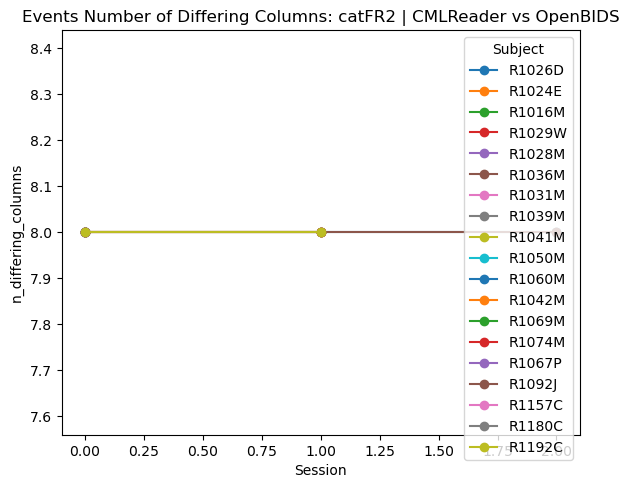

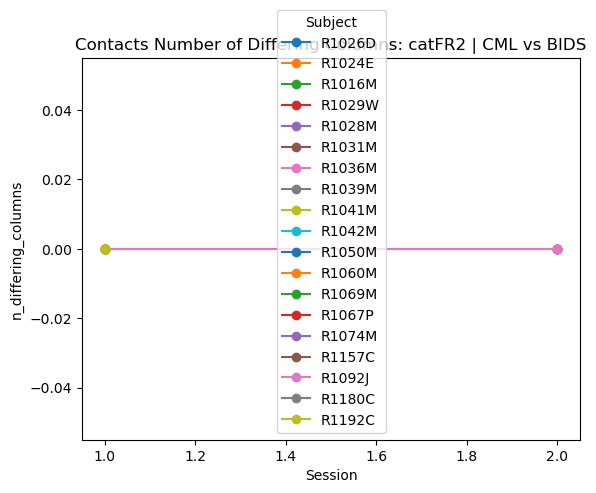

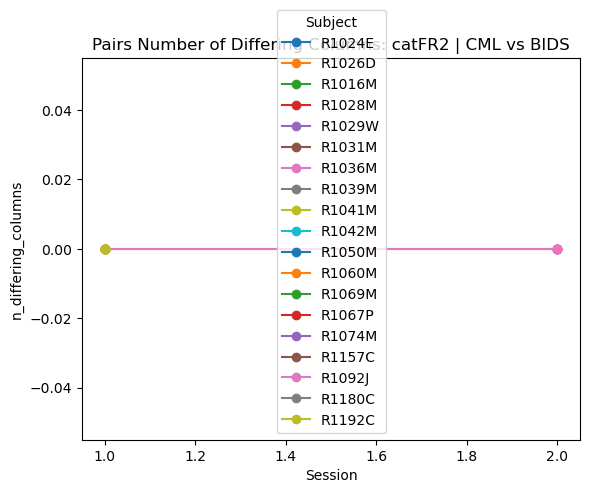

2026-04-22 19:11:53,399 - distributed.deploy.adaptive_core - INFO - Adaptive stop
2026-04-22 19:11:53,400 - distributed.deploy.adaptive_core - INFO - Adaptive stop
2026-04-22 19:11:53,401 - distributed.deploy.adaptive_core - INFO - Adaptive stop


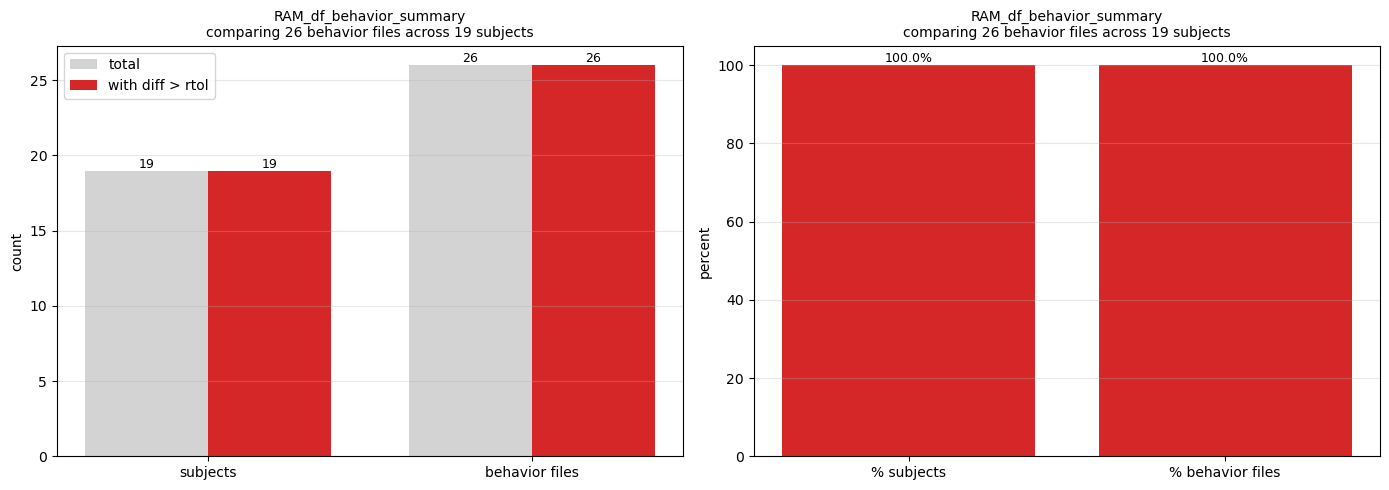

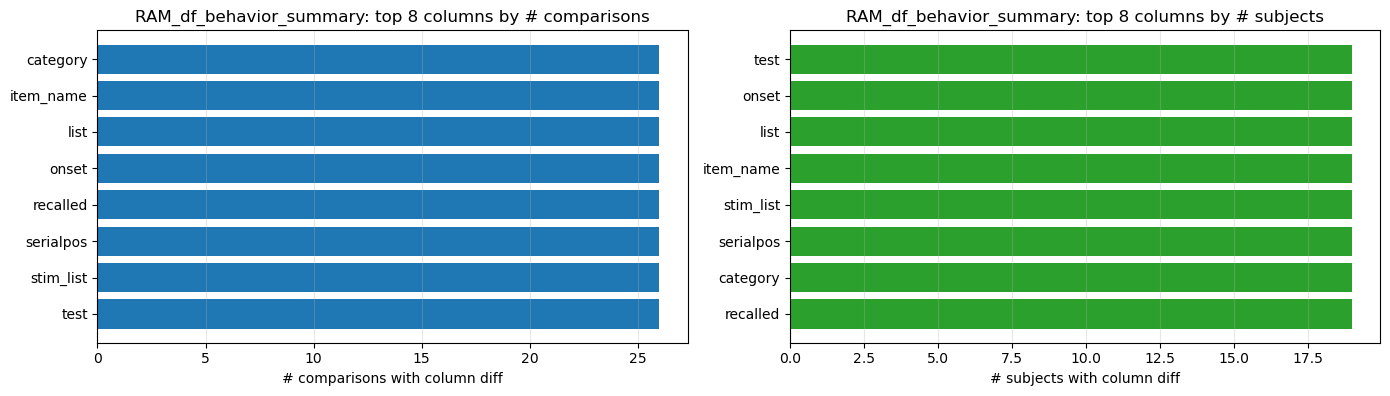

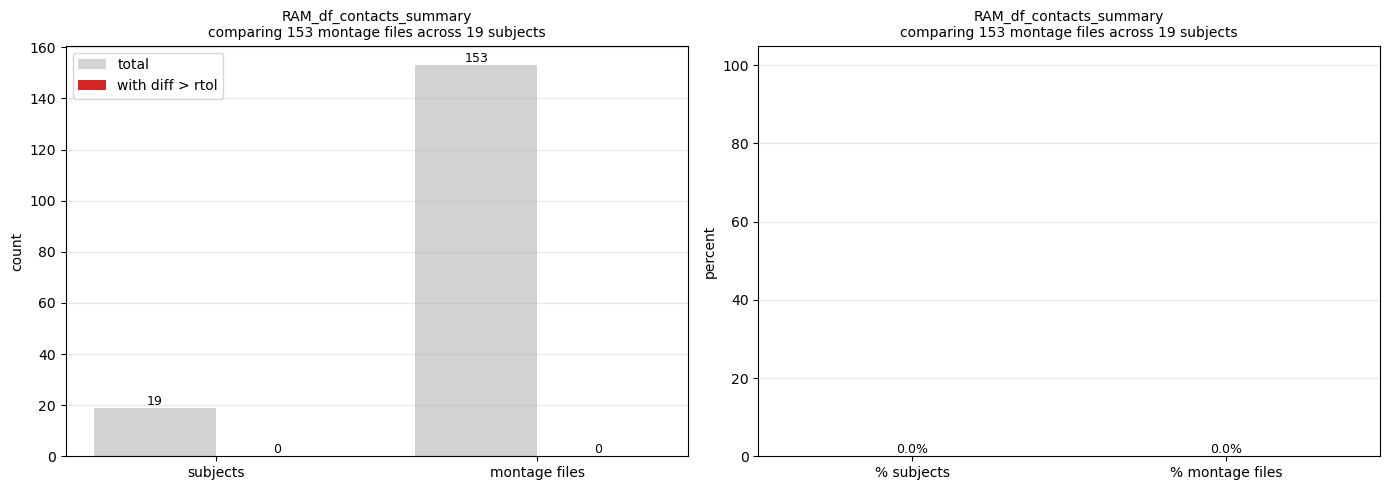

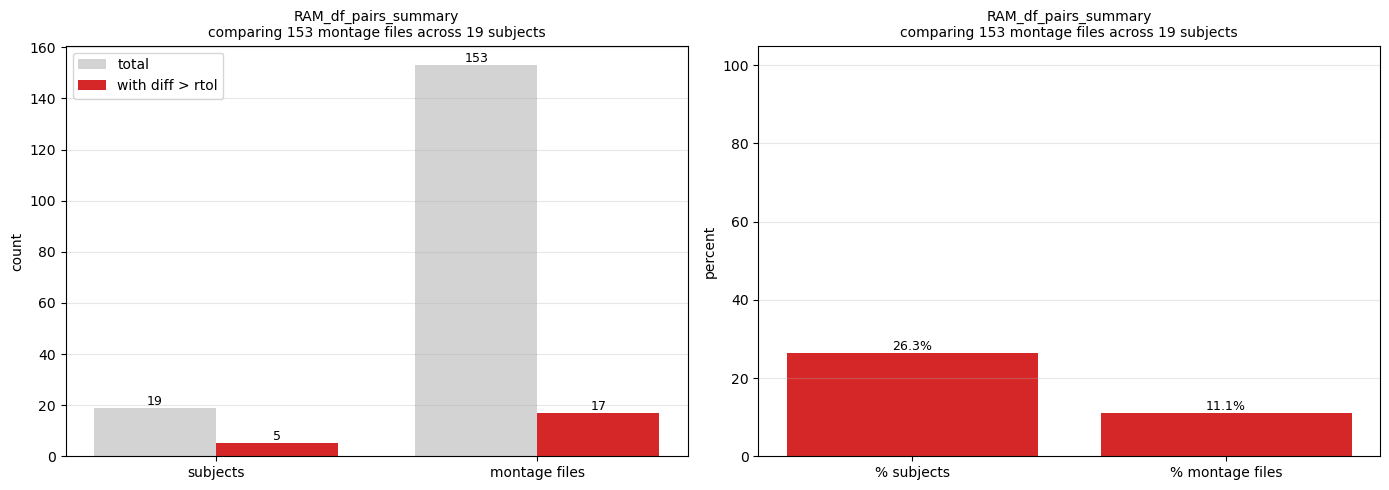

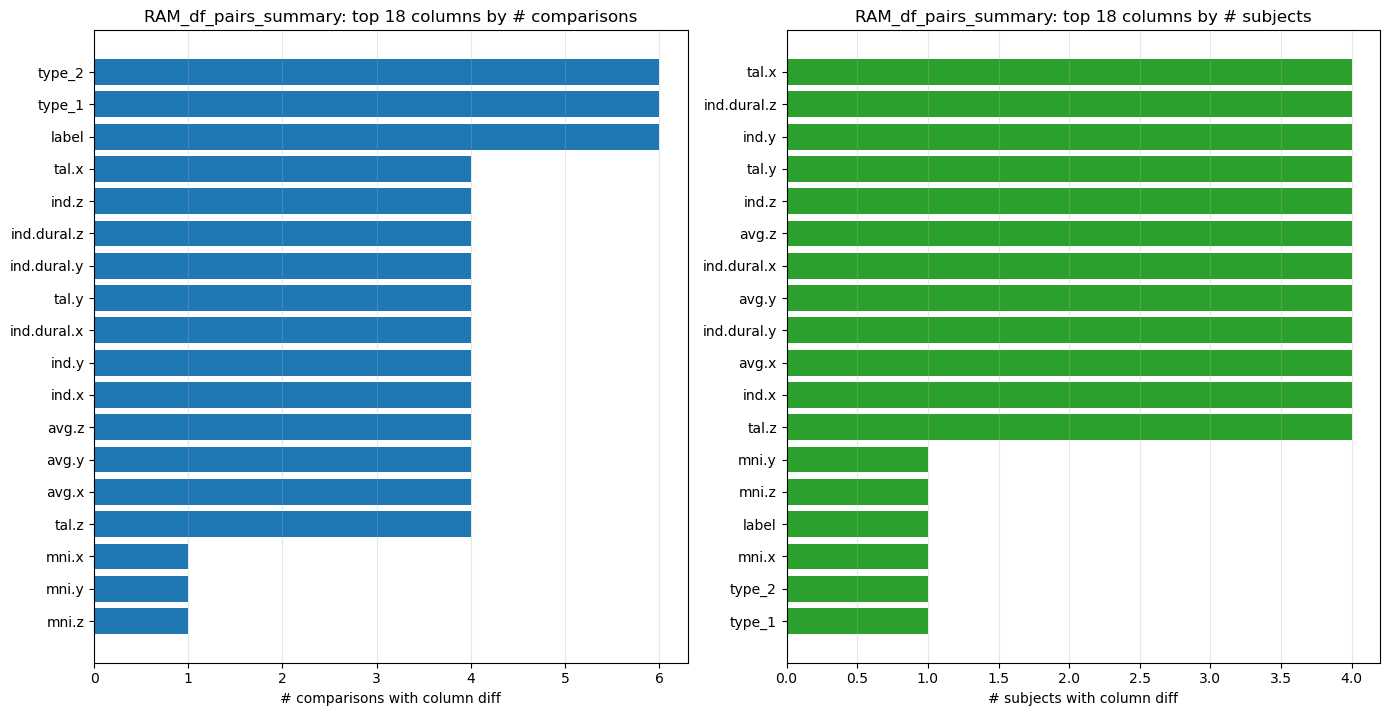

In [25]:
for k in ram_dfs.keys():
    if ram_dfs[k] is not None and "differing_columns" in ram_dfs[k].columns:
        ram_dfs[k]['n_differing_columns'] = ram_dfs[k]["differing_columns"].apply(_safe_col_len)

# --- Behavioral plots ---
if "df_behavior_summary" in ram_dfs:
    plot_comparison_results(ram_dfs["df_behavior_summary"], "n_differing_columns", title="Events Number of Differing Columns")

if "df_contacts_summary" in ram_dfs:
    plot_comparison_results(ram_dfs["df_contacts_summary"], "n_differing_columns", title="Contacts Number of Differing Columns")

if "df_pairs_summary" in ram_dfs:
    plot_comparison_results(ram_dfs["df_pairs_summary"], "n_differing_columns", title="Pairs Number of Differing Columns")


# --- New: per-pipeline summary stats + plots (saved to disk) ---
# Use df_ram (the BIDS data index for jobs) as ground truth for denominators.
ram_expected = expected_from_jobs(df_ram)
ram_stats = run_all_plots(ram_dfs, name="RAM", save_dir=ram_final, expected=ram_expected)

del ram_dfs

In [ ]:
FILE_CATEGORIES_RAM = [
    "df_epoch_summary", "df_epoch_time",
]

ram_dfs = load_dfs(FILE_CATEGORIES_RAM,ram_final)


df_epoch_summary: loaded 988 rows from results/FR1_final_bdf/df_epoch_summary_all.csv
df_epoch_time: loaded 7241 rows from results/FR1_final_bdf/df_epoch_time_all.csv


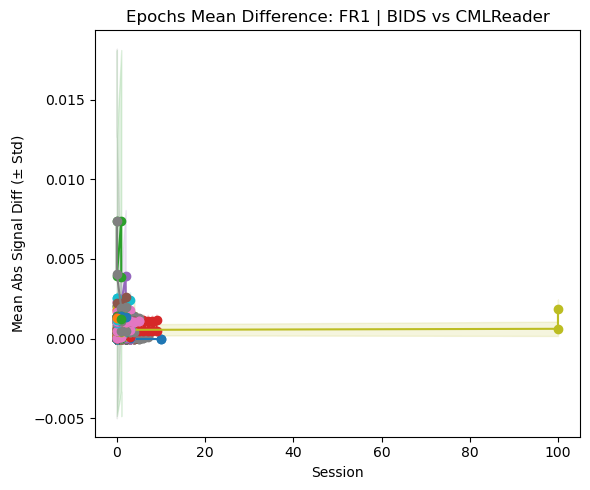

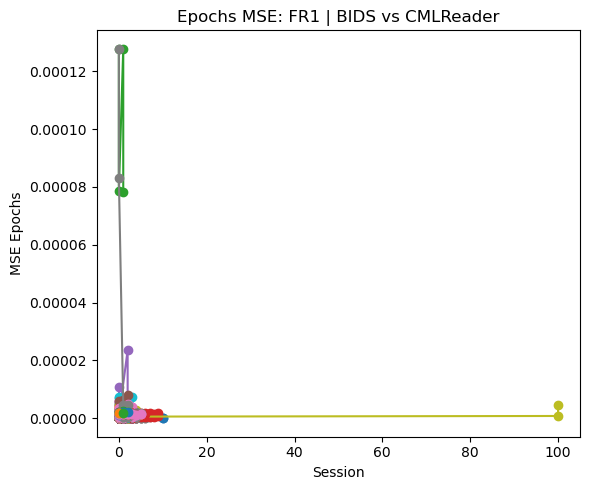

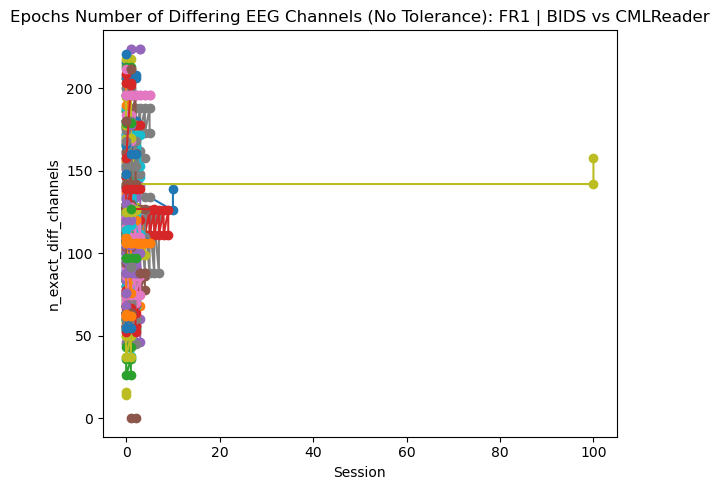

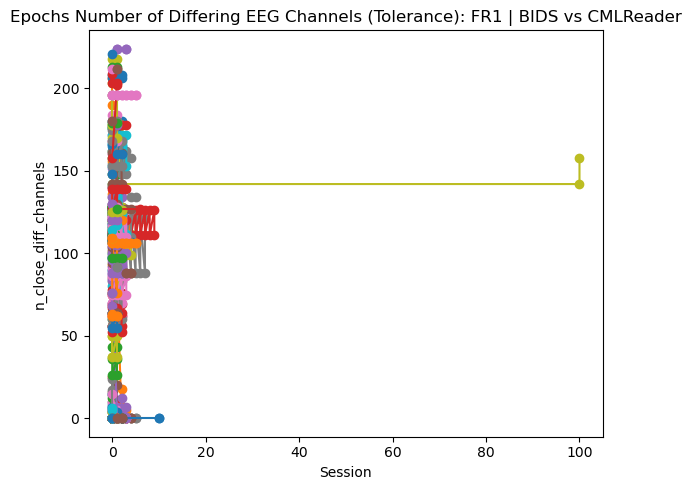

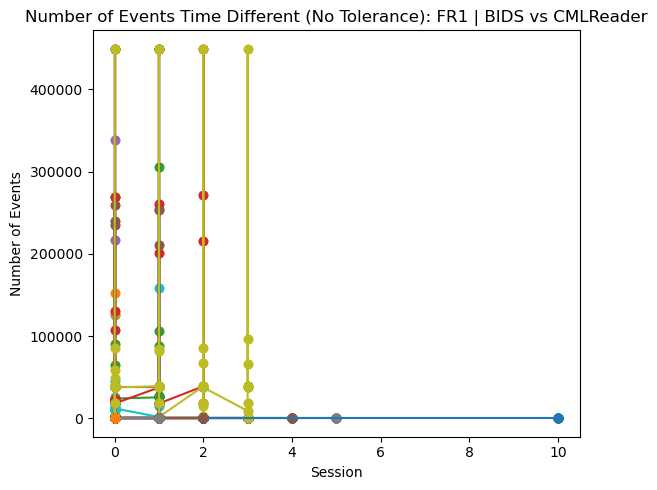

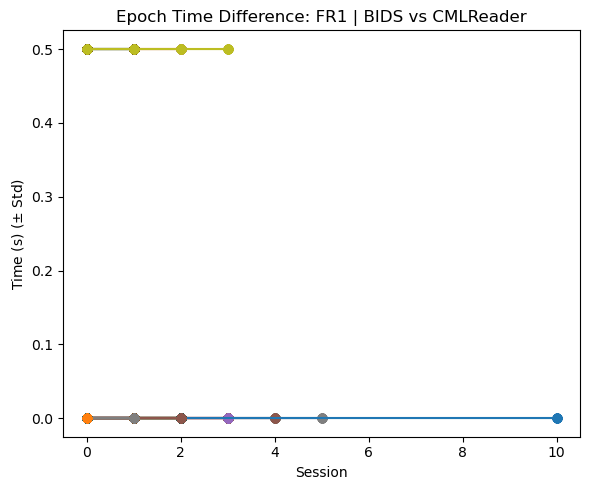

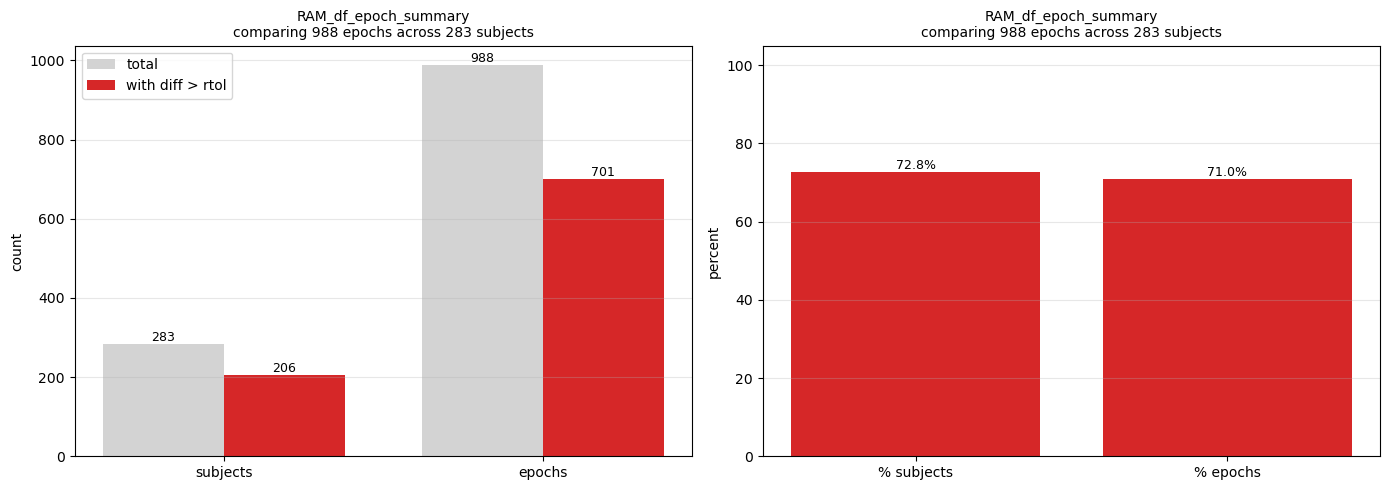

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


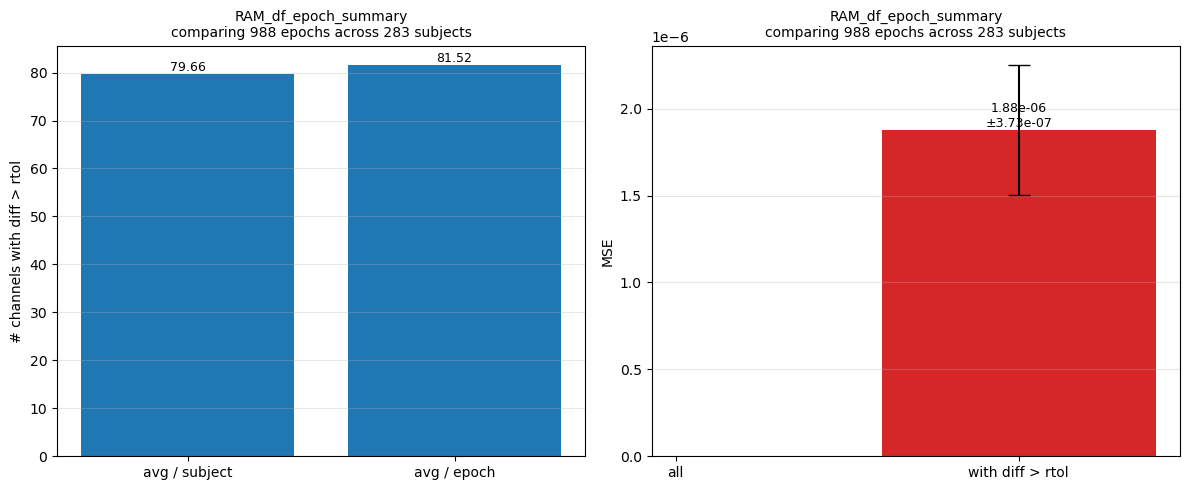

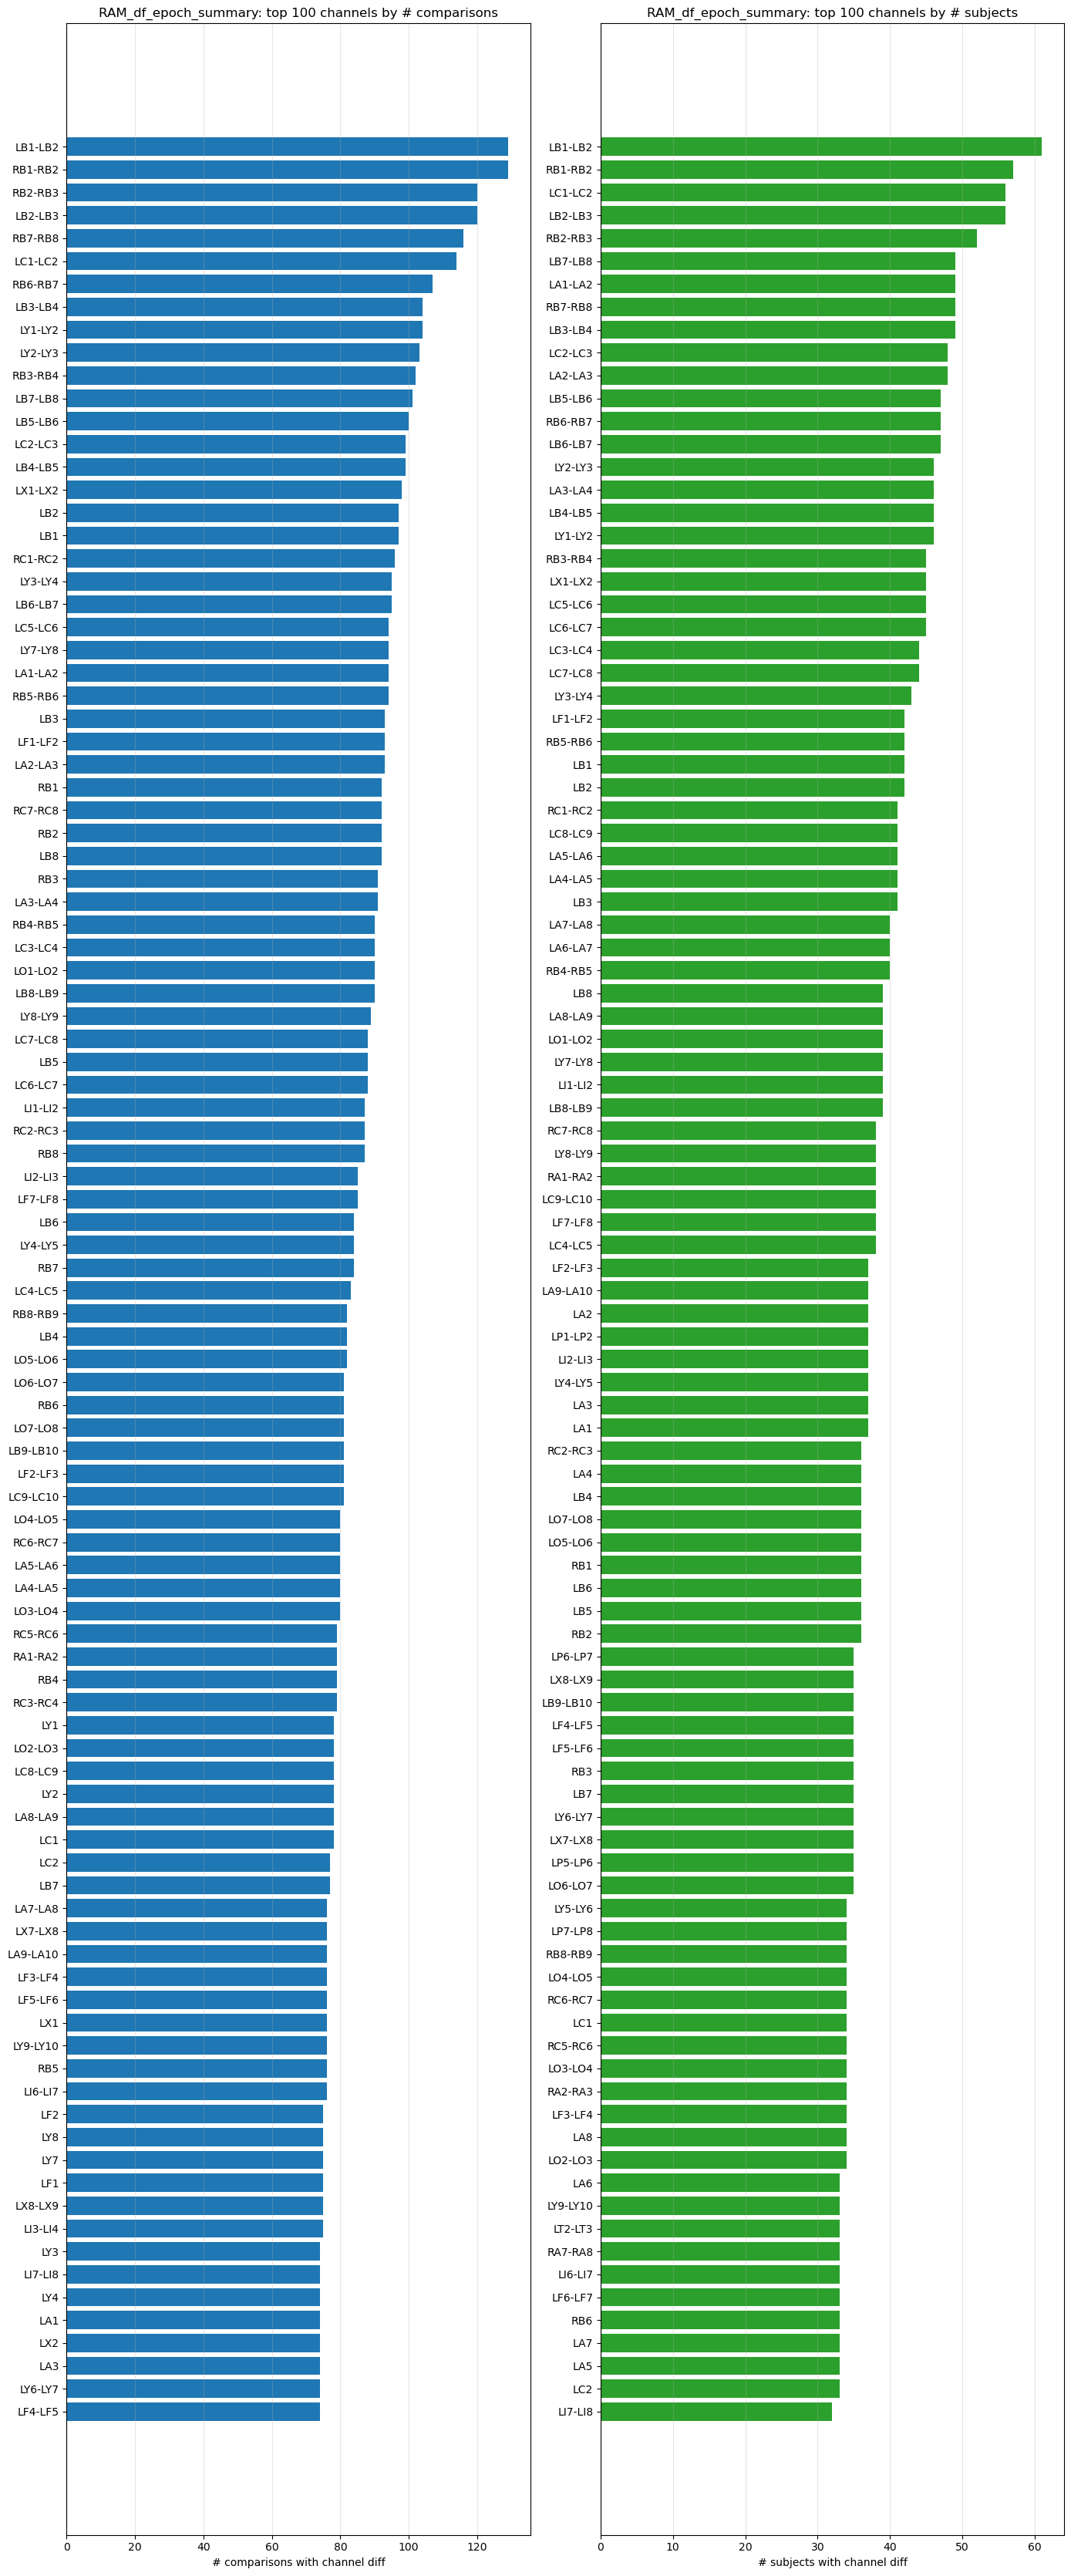

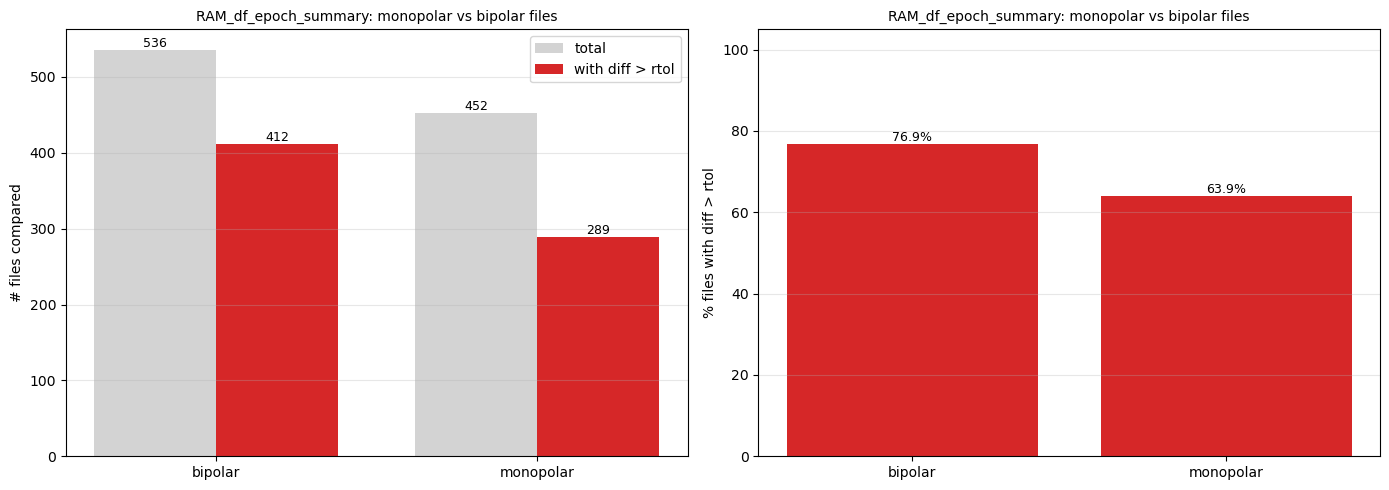

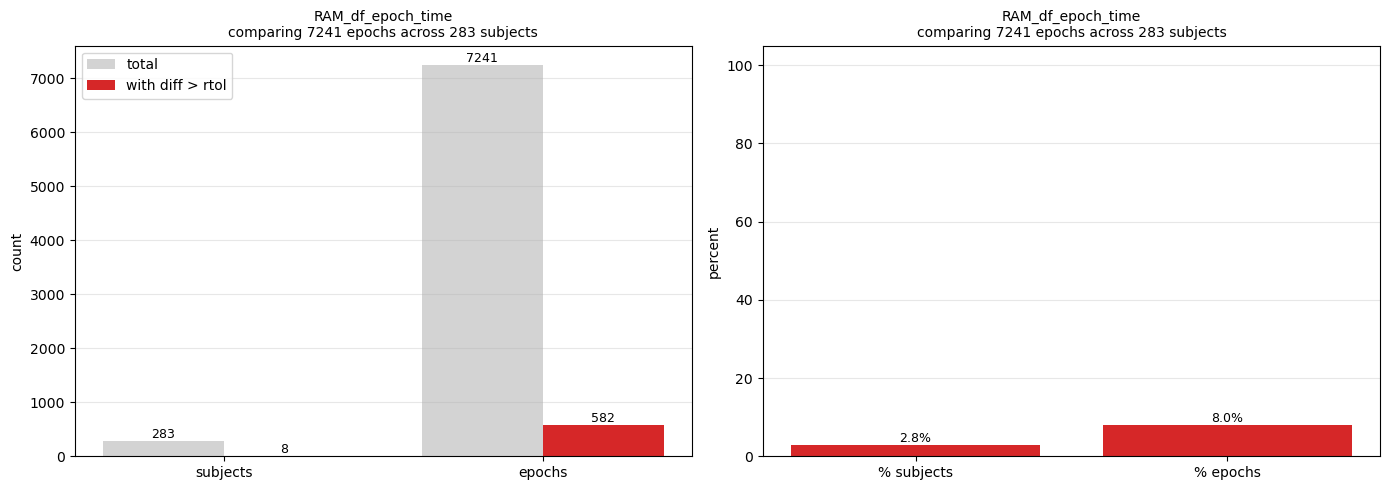

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


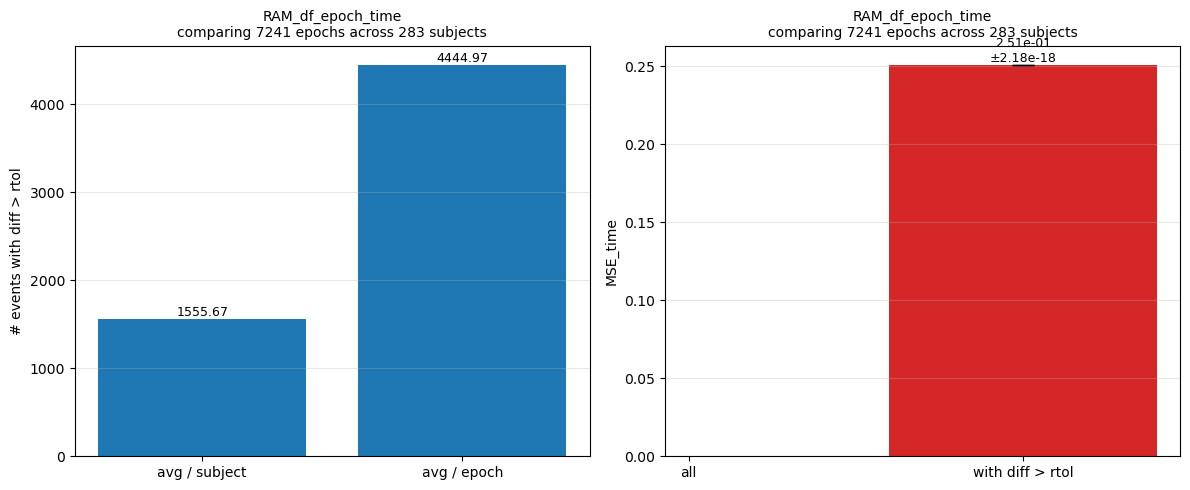

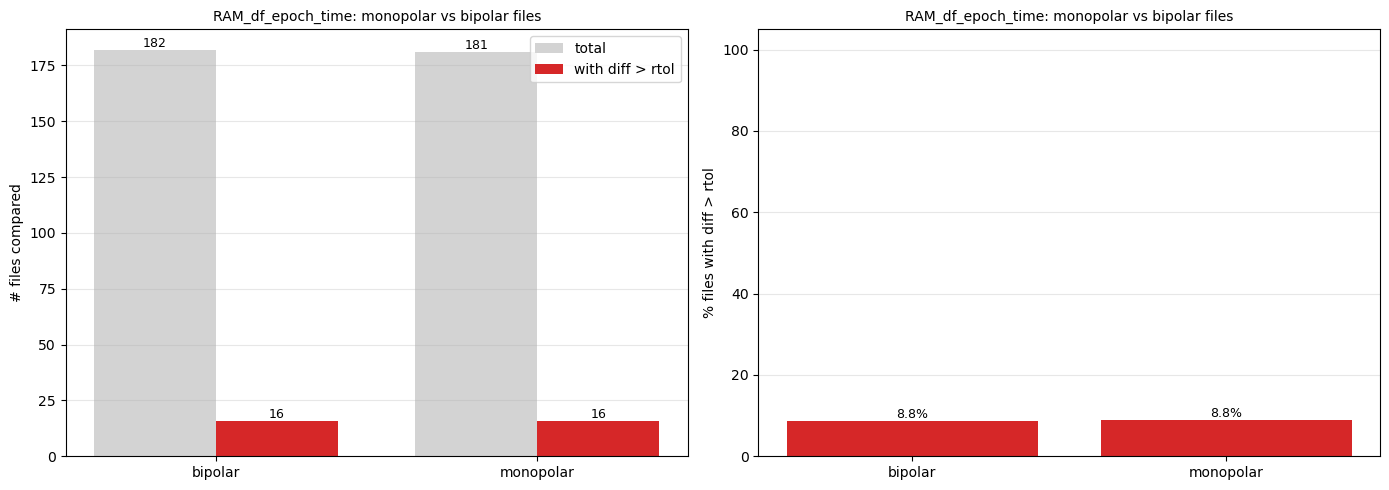

In [ ]:
# --- Helper: if summary has per-event rows, aggregate to one row per (subject, session, acquisition) ---
def aggregate_epoch_summary(df):
    """Keep only 'ALL' rows if present, otherwise average over event types."""
    if "event_type" in df.columns and "ALL" in df["event_type"].values:
        return df[df["event_type"] == "ALL"].copy()
    # Fallback: average numeric columns, keep first of non-numeric
    group_cols = ["subject", "experiment", "session", "comparison", "source_a", "source_b"]
    if "acquisition" in df.columns:
        group_cols.append("acquisition")
    group_cols = [c for c in group_cols if c in df.columns]
    return df.groupby(group_cols, as_index=False).mean(numeric_only=True)
# ram_dfs = aggregate_epoch_summary(ram_dfs[])
# --- Raw signal plots ---
if "df_epoch_summary" in ram_dfs:
    epoch_summary = aggregate_epoch_summary(ram_dfs["df_epoch_summary"])
    plot_comparison_results(epoch_summary, "mean_abs_diff", "std_diff", col_label="Mean Abs Signal Diff", title="Epochs Mean Difference")
    plot_comparison_results(epoch_summary, "mse", col_label="MSE Epochs", title="Epochs MSE")
    plot_comparison_results(epoch_summary, "n_exact_diff_channels", title="Epochs Number of Differing EEG Channels (No Tolerance)")
    plot_comparison_results(epoch_summary, "n_close_diff_channels", title="Epochs Number of Differing EEG Channels (Tolerance)")

if "df_epoch_time" in ram_dfs:
    plot_comparison_results(ram_dfs["df_epoch_time"], "n_close_time_diff", col_label="Number of Events", title="Number of Events Time Different (No Tolerance)")
    plot_comparison_results(ram_dfs["df_epoch_time"], "mean_abs_time_diff","std_time_diff", col_label="Time (s)", title="Epoch Time Difference")


# --- New: per-pipeline summary stats + plots (saved to disk) ---
ram_expected = expected_from_jobs(df_ram)
ram_stats = run_all_plots(ram_dfs, name="RAM", save_dir=ram_final, expected=ram_expected)

del ram_dfs

In [26]:
FILE_CATEGORIES_RAM = [
    "df_digital_summary"
]

ram_dfs = load_dfs(FILE_CATEGORIES_RAM, ram_final)


df_digital_summary: loaded 52 rows from /home1/zrentala/eeg-validation/results/catFR2_final_pyedflib/df_digital_summary_all.csv


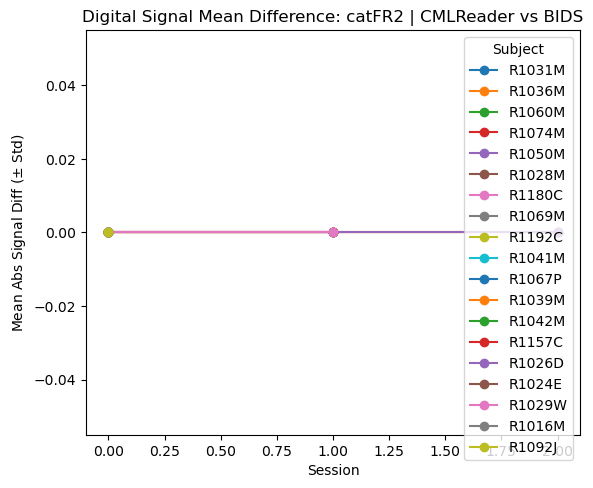

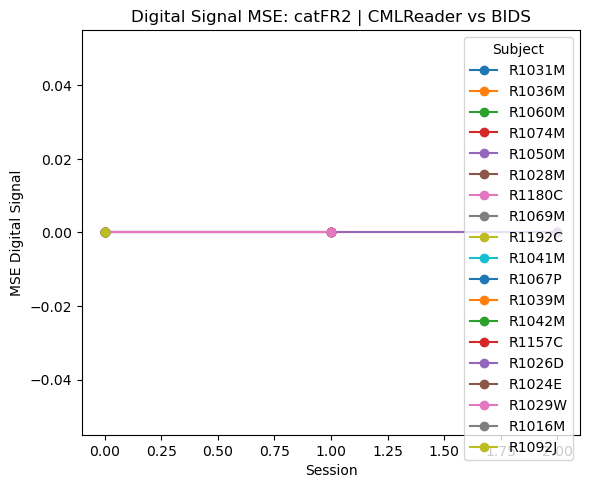

In [27]:
if "df_digital_summary" in ram_dfs:
    plot_comparison_results(ram_dfs["df_digital_summary"].query('subject != "R1006_"'), "mean_abs_diff", "std_diff", col_label="Mean Abs Signal Diff", title="Digital Signal Mean Difference")
    plot_comparison_results(ram_dfs["df_digital_summary"].query('subject != "R1006_"'), "mse", col_label="MSE Digital Signal", title="Digital Signal MSE")
    # plot_comparison_results(ram_dfs["df_digital_summary"].query('subject != "R1006_"'), "n_exact_diff_channels", title="Raw Signal Number of Differing EEG Channels (No Tolerance)")
    # plot_comparison_results(ram_dfs["df_digital_summary"].query('subject != "R1006_"'), "n_close_diff_channels", title="Raw Signal Number of Differing EEG Channels (Tolerance)")
    
# --- New: per-pipeline summary stats + plots (saved to disk) ---
ram_expected = expected_from_jobs(df_ram)
ram_stats = run_all_plots(ram_dfs, name="RAM", save_dir=ram_final, expected=ram_expected)

del ram_dfs

In [28]:
FILE_CATEGORIES_RAM = [
    "df_raw_summary", "df_raw_time",
]

ram_dfs = load_dfs(FILE_CATEGORIES_RAM, ram_final)


df_raw_summary: loaded 52 rows from /home1/zrentala/eeg-validation/results/catFR2_final_pyedflib/df_raw_summary_all.csv
Skipping df_raw_time (file not found: /home1/zrentala/eeg-validation/results/catFR2_final_pyedflib/df_raw_time_all.csv)


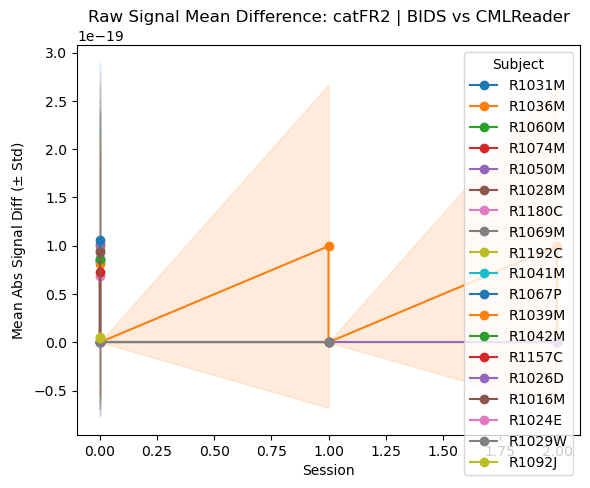

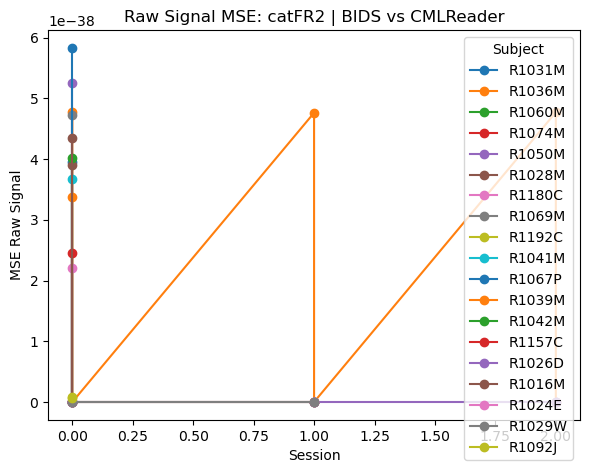

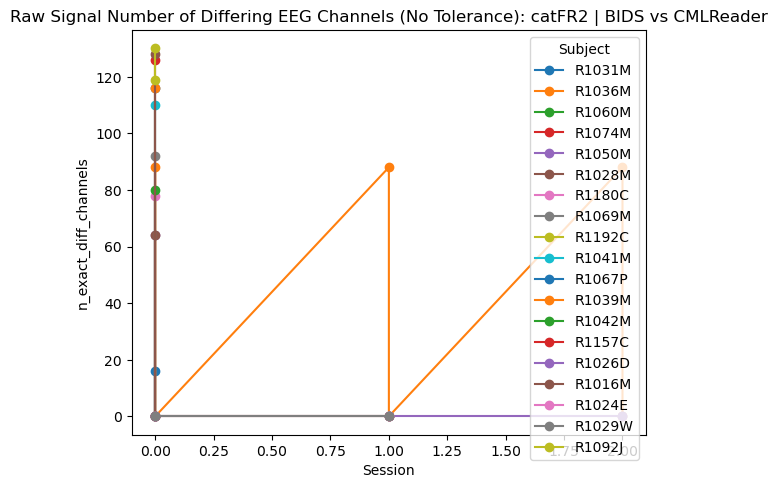

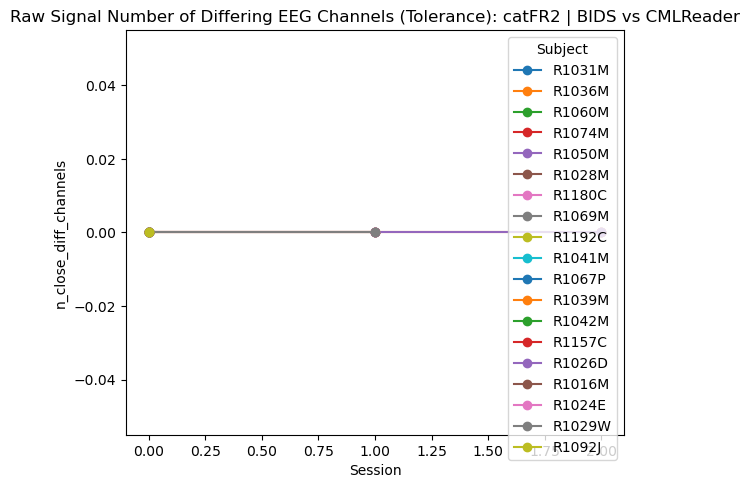

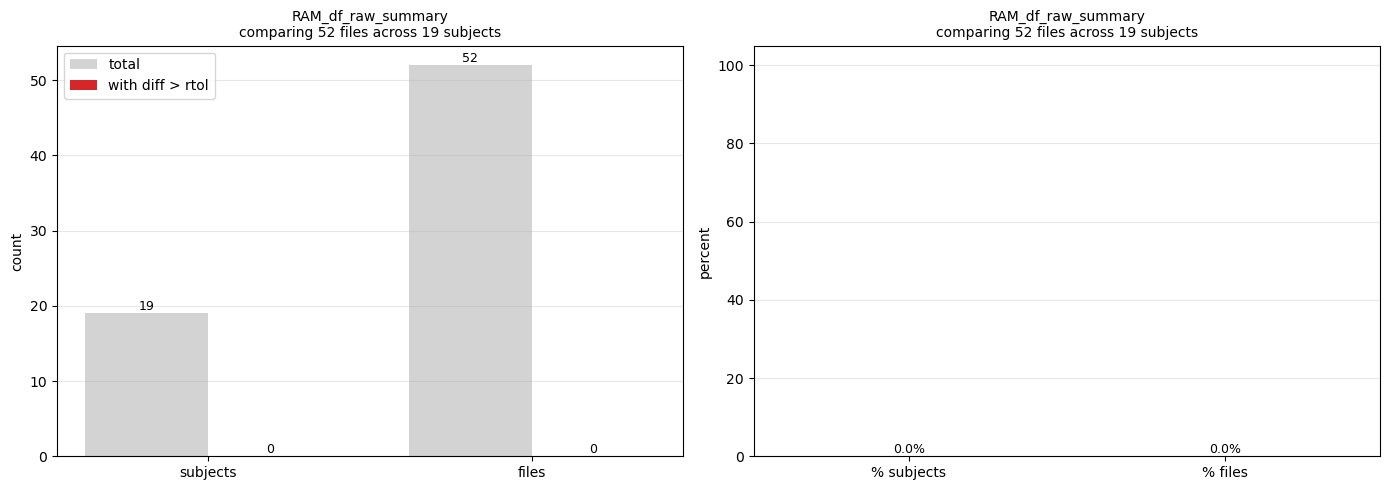

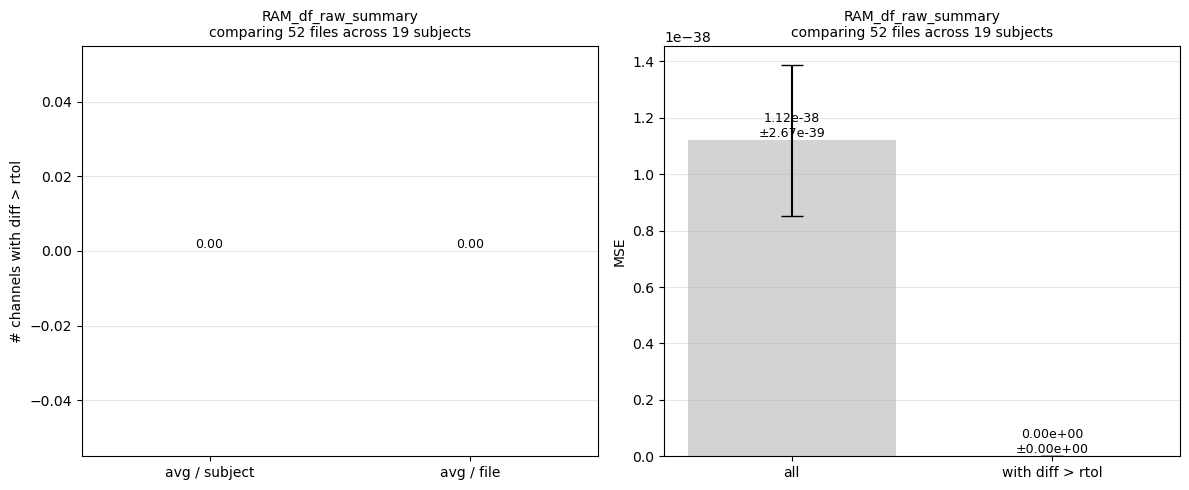

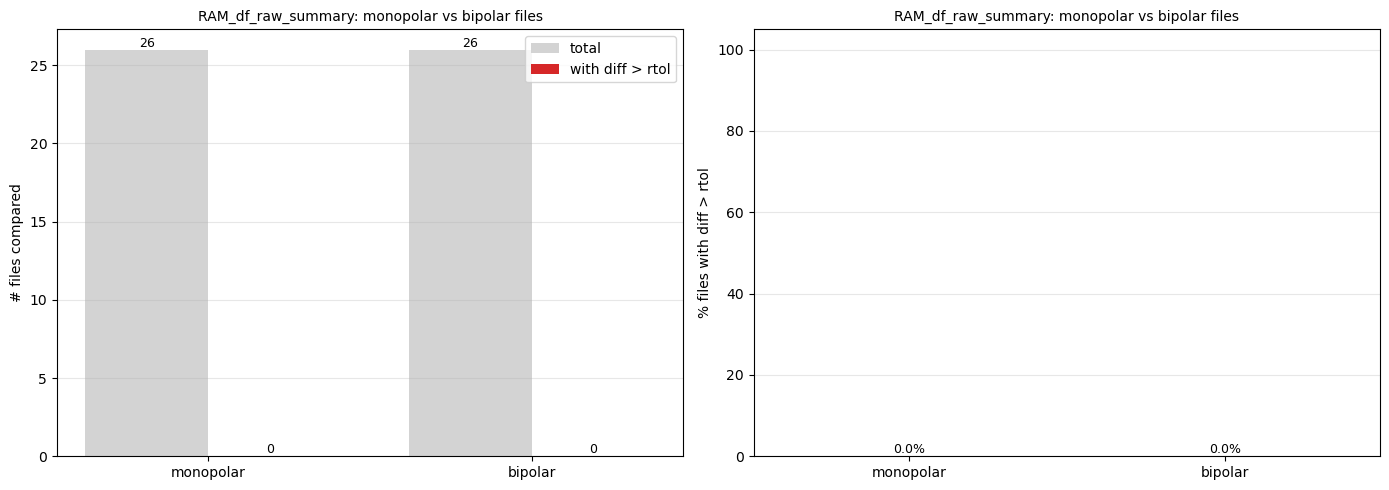

In [29]:
if "df_raw_summary" in ram_dfs:
    plot_comparison_results(ram_dfs["df_raw_summary"].query('subject != "R1006_"'), "mean_abs_diff", "std_diff", col_label="Mean Abs Signal Diff", title="Raw Signal Mean Difference")
    plot_comparison_results(ram_dfs["df_raw_summary"].query('subject != "R1006_"'), "mse", col_label="MSE Raw Signal", title="Raw Signal MSE")
    plot_comparison_results(ram_dfs["df_raw_summary"].query('subject != "R1006_"'), "n_exact_diff_channels", title="Raw Signal Number of Differing EEG Channels (No Tolerance)")
    plot_comparison_results(ram_dfs["df_raw_summary"].query('subject != "R1006_"'), "n_close_diff_channels", title="Raw Signal Number of Differing EEG Channels (Tolerance)")
    
if "df_raw_time" in ram_dfs:
    # plot_comparison_results(ram_dfs["df_raw_time"], "n_close_time_diff", col_label="Number of Events", title="Number of Events Different (No Tolerance)")
    plot_comparison_results(ram_dfs["df_raw_time"], "mean_abs_time_diff","std_time_diff", col_label="Time (s)", title="Raw Time Difference")


# --- New: per-pipeline summary stats + plots (saved to disk) ---
ram_expected = expected_from_jobs(df_ram)
ram_stats = run_all_plots(ram_dfs, name="RAM", save_dir=ram_final, expected=ram_expected)

del ram_dfs

In [ ]:
# ---- VFFR diagnostic: is the MSE caused by Status / EXG channels? ----
# Loads LTP229 VFFR session 0, runs the comparator three times:
#   (a) all channels (matches what RawSignalPipeline saves)
#   (b) drop the BioSemi `Status` channel
#   (c) also drop the EXG1..EXG8 auxiliary channels
# If (b) or (c) brings mse / max_abs_diff down by orders of magnitude,
# the per-session VFFR mse spread is driven by those channels and not by
# the `eeg_cml / self.conversion_to_v` step in raw_signal.py:49.

from eeg_validation.loaders.cml import load_cml_eeg_raw
from eeg_validation.loaders.bids import load_bids_raw, raw_to_xarray, get_reader
from eeg_validation.comparators.signal import SignalComparator

SUB, EXP, SESS = "LTP229", "VFFR", 0

# --- Load CML side (same call the pipeline uses) ---
eeg_cml = load_cml_eeg_raw(SUB, EXP, SESS)
print(f"CML  shape={eeg_cml.shape}  dtype={eeg_cml.dtype}")
print(f"     min={float(eeg_cml.min()):.6g}  max={float(eeg_cml.max()):.6g}  mean={float(eeg_cml.mean()):.6g}")

# --- Load BIDS side via the same reader the pipeline uses ---
reader = get_reader(SUB, EXP, SESS, "/data/LTP_BIDS/VFFR")
raw_bids = load_bids_raw(reader, acquisition=None)
raw_bids.load_data()
eeg_bids = raw_to_xarray(raw_bids, convert_ms=True)
print(f"BIDS shape={eeg_bids.shape}  dtype={eeg_bids.values.dtype}")
print(f"     min={float(eeg_bids.min()):.6g}  max={float(eeg_bids.max()):.6g}  mean={float(eeg_bids.mean()):.6g}")
print()

# --- Apply the same /conversion_to_v default the pipeline applies for VFFR ---
# (VFFR is not in system_1_unit_conversions.csv, so the pipeline falls back to 1e6.)
eeg_cml = eeg_cml / 1e6
print(f"After /1e6: CML min={float(eeg_cml.min()):.6g}  max={float(eeg_cml.max()):.6g}")
print()

# --- Run the comparator three ways ---
def _drop(da, names):
    keep = [c for c in da.channel.values if c not in set(names)]
    return da.sel(channel=keep)

def _run(label, a, b):
    res = SignalComparator().compare(
        a, b, label_a="BIDS", label_b="CMLReader",
        subject=SUB, experiment=EXP, session=SESS, acquisition="scalp",
    )
    s = res.df_summary.iloc[0]
    print(f"  {label:25s}  n_ch={int(s['n_common_channels']):3d}  "
          f"mean_abs_diff={s['mean_abs_diff']:.4g}  "
          f"max_abs_diff={s['max_abs_diff']:.4g}  "
          f"std_diff={s['std_diff']:.4g}  "
          f"mse={s['mse']:.4g}")
    return s

print("=== Comparator output, three drop levels ===")
_run("(a) all channels",                 eeg_bids, eeg_cml)

drop_status = ["Status"]
_run("(b) drop Status",
     _drop(eeg_bids, drop_status), _drop(eeg_cml, drop_status))

drop_status_exg = ["Status"] + [f"EXG{i}" for i in range(1, 9)]
_run("(c) drop Status + EXG1-8",
     _drop(eeg_bids, drop_status_exg), _drop(eeg_cml, drop_status_exg))


Extracting EDF parameters from /protocols/ltp/subjects/LTP229/experiments/VFFR/sessions/0/ephys/current_processed/LTP229_session_0.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9539583  =      0.000 ...  4658.000 secs...


KeyboardInterrupt: 